## 0. Libraries

In [ ]:
!pip install casadi

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import casadi as ca
import time
import scipy.linalg as la
import pandas as pd
import seaborn as sns
import scipy.stats as stats
import contextlib
import os

## 1. Batch Model (between feedings)

The paper implements fed-batch by running the **pure batch** model between the sampling/feed times, and applies the bolus instantaneously at the end of each interval (Table 2 of the paper).

**State Variables:** `X(t) = [Xv, P, glc, glu, gln, amm, lac, μ]`  
**Parameters (θ, 13 in all):**  
`[μ_max, k_d, K_glc, Y_{X/glc}, Y_{X/gln}, Y_{X/glu}, Y_{lac/glc}, Y_{X/amm},
Y_{gln/glu}, Y_{X/lac}, m_glc, Y_{P/X}, KD_amm]`

**Global constant (not a parameter to be returned):**
`α_glc` — glucose threshold for the lactate switch

In [ ]:
def mckm_batch_rhs(t, X, p):
    """
    RHS of the MCKM BATCH model (between feedings).
    Consistent with Equations 2-17 from Sietaram et al. (2025).

    State: X = [Xv, P, glc, glu, gln, amm, lac, mu]

    Parameters (dict p):
        mu_max   : maximum growth rate [h⁳]
        kD        : death constant [h⁳]
        K_glc     : glucose semi-saturation constant [mM]
        KD_amm    : ammonium inhibition constant [mM]
        Y_PX      : mAb/biomass yield [mg/10⁶cells]
        Y_X_glc   : biomass/glucose yield [10⁶cells/mM]
        Y_X_glu   : biomass/glutamate yield [10⁶cells/mM]
        Y_gln_glu : glutamine/glutamate yield [mM/mM]
        Y_X_gln   : biomass/glutamine yield [10⁶cells/mM]
        Y_X_amm   : biomass/ammonium yield [10⁶cells/mM]
        Y_lac_glc : lactate/glucose yield [mM/mM]
        Y_X_lac   : biomass/lactate yield (consumption) [10⁶cells/mM]
        m_glc     : glucose maintenance [mMh⁳/10⁶cells]
        alpha_glc : glucose threshold for lactate switch [mM] (global constant)
    """
    Xv, P, glc, glu, gln, amm, lac, mu = X

    # Avoid numerical issues (concentrations cannot be negative)
    Xv  = max(Xv,  0.0)
    glc = max(glc, 0.0)
    glu = max(glu, 0.0)
    gln = max(gln, 0.0)
    amm = max(amm, 0.0)
    lac = max(lac, 0.0)
    mu  = max(mu,  0.0)

    # Parameters
    mu_max    = p["mu_max"]
    kD        = p["kD"]
    K_glc     = p["K_glc"]
    KD_amm    = p["KD_amm"]
    Y_PX      = p["Y_PX"]
    Y_X_glc   = p["Y_X_glc"]
    Y_X_glu   = p["Y_X_glu"]
    Y_gln_glu = p["Y_gln_glu"]
    Y_X_gln   = p["Y_X_gln"]
    Y_X_amm   = p["Y_X_amm"]
    Y_lac_glc = p["Y_lac_glc"]
    Y_X_lac   = p["Y_X_lac"]
    m_glc     = p["m_glc"]
    alpha_glc = p["alpha_glc"]

    # Specific rates (Eqs. 3, 4, 6, 8, 10, 12, 14)

    # Eq. 4: Death rate (ammonium function)
    mu_d = kD * amm / (KD_amm + amm)

    # Eq. 6: mAb production (Luedeking-Piret)
    qP = mu * Y_PX

    # Eq. 8: Glucose consumption (Luedeking-Piret + maintenance)
    qglc = mu / Y_X_glc + m_glc

    # Eq. 10: Glutamate consumption
    qglu = mu / Y_X_glu

    # Eq. 12: Glutamine consumption
    qgln = mu / Y_X_gln

    # Eq. 14: Ammonium production
    qamm = mu / Y_X_amm

    # Eq. 16: Lactate switch
    # If glc > alpha_glc: lactate production (proportional to glucose consumption)
    # If glc <= alpha_glc: net lactate consumption
    if glc > alpha_glc:
        qlac = Y_lac_glc * qglc
    else:
        qlac = -mu / Y_X_lac + Y_lac_glc * qglc

    # ODEs (Batch Model, without feeding terms)

    # Eq. 2: Viable biomass
    dXv_dt  = (mu - mu_d) * Xv

    # Eq. 5: mAb
    dP_dt   = qP * Xv

    # Eq. 7 (batch version): Glucose
    # In the batch model (between feedings) there is NO feeding term.
    # The paper explicitly removes feeding terms for the batch (Table 2).
    dglc_dt = -qglc * Xv

    # Eq. 9 (batch version): Glutamate
    dglu_dt = -qglu * Xv

    # Eq. 11: Glutamine
    # Produced by the GS system from glutamate, consumed for synthesis
    dgln_dt = -qgln * Xv + Y_gln_glu * qglu * Xv

    # Eq. 13: Ammonium
    damm_dt = qamm * Xv

    # Eq. 15: Lactate
    dlac_dt = qlac * Xv

    # Eq. 17: Additional ODE for ̃
    # Derivative of Eq. 3 with respect to time (quotient rule)
    # IMPORTANT: dglc_dt here is the batch model one (-qglc * Xv)
    dmu_dt  = mu_max * K_glc / (K_glc + glc)**2 * dglc_dt

    return [dXv_dt, dP_dt, dglc_dt, dglu_dt, dgln_dt, damm_dt, dlac_dt, dmu_dt]

## 2. Bolus Application (Discrete Feeding)

Bolus of glucose and glucose is added at the end of each interval.
An instantaneous mass balance is performed (perfect mixing).

In [ ]:
def apply_bolus_feed(X_end, V_before, V_feed, glc_feed, glu_feed):
    """
    Applies the instantaneous glucose and glutamate bolus at the end of an interval.

    Parameters:
        X_end    : state at the end of the interval [Xv, P, glc, glu, gln, amm, lac, mu]
        V_before : volume before the bolus [L]
        V_feed   : bolus volume [L]
        glc_feed : glucose concentration in the feed [mM]
        glu_feed : glutamate concentration in the feed [mM]

    Returns:
        X_post   : state after the bolus
        V_after  : volume after the bolus [L]
    """
    X_post = np.array(X_end, dtype=float).copy()
    V_after = V_before + V_feed
    f = V_before / V_after  # dilution factor

    Xv, P, glc, glu, gln, amm, lac, mu = X_post

    # Glucose and glutamate: mass balance with the feed
    X_post[2] = (glc * V_before + glc_feed * V_feed) / V_after
    X_post[3] = (glu * V_before + glu_feed * V_feed) / V_after

    # Other concentrations are diluted by the volume change
    X_post[0] = Xv  * f  # Xv
    X_post[1] = P   * f  # mAb
    X_post[4] = gln * f  # glutamine
    X_post[5] = amm * f  # ammonium
    X_post[6] = lac * f  # lactate

    # mu is NOT diluted (it is not a physical concentration)
    # X_post[7] = mu  (no change)

    return X_post, V_after

## 3. Fed-Batch Simulation (Interval Iteration)

Implements the pseudocode: Runs the batch between sampling intervals, accumulate the error, and applies the bolus at the end of each interval.

In [ ]:
def simulate_mckm_fedbatch(
    params,
    X0,
    t_samples,
    V0,
    feed_times,
    feed_volumes,
    glc_feed,
    glu_feed,
    method="Radau",
    rtol=1e-7,
    atol=1e-9
):
    """
    Simulates the MCKM fed-batch model.

    The batch model runs between the sampling times t_samples.
    The bolus is applied at the START of the next interval (right after sampling),
    starting from the second sampling time (as in the paper: feeding
    begins after the second sampling).

    Parameters:
        params       : dict with kinetic parameters
        X0           : initial condition [Xv, P, glc, glu, gln, amm, lac, mu]
        t_samples    : sampling times [h] (T=7 in the paper: days 0, 3, 6, 8, 10, 13, 15)
        V0           : initial volume [L]
        feed_times   : indices (in t_samples) where the bolus occurs (after sampling)
        feed_volumes : volume of each bolus [L] (same order as feed_times)
        glc_feed     : glucose concentration in the feed [mM]
        glu_feed     : glutamate concentration in the feed [mM]

    Returns:
        all_t : array of time points
        all_X : array of states (shape: N_times x 8)
    """
    t_samples = np.asarray(t_samples, dtype=float)
    n_intervals = len(t_samples) - 1

    all_t = []
    all_X = []

    X_current = np.array(X0, dtype=float)
    V_current = float(V0)

    # Build map: interval index -> bolus volume to apply at the START
    # The paper feeds right after sampling (at the start of the next interval)
    bolus_map = {}
    for i, idx_feed in enumerate(feed_times):
        bolus_map[idx_feed] = feed_volumes[i]

    for i in range(n_intervals):
        t0 = t_samples[i]
        tf = t_samples[i + 1]

        # Apply bolus at the START of the interval (if applicable)
        # The paper states: feeding occurs right after sampling
        if i in bolus_map:
            V_feed_i = bolus_map[i]
            X_current, V_current = apply_bolus_feed(
                X_current, V_current, V_feed_i, glc_feed, glu_feed
            )

        # Integrate the batch model in the interval [t0, tf]
        t_eval = np.linspace(t0, tf, 100)

        sol = solve_ivp(
            fun=lambda t, X: mckm_batch_rhs(t, X, params),
            t_span=(t0, tf),
            y0=X_current,
            t_eval=t_eval,
            method=method,
            rtol=rtol,
            atol=atol
        )

        if not sol.success:
            raise RuntimeError(f"Integration failed at interval {i} [{t0}, {tf}h]: {sol.message}")

        # Accumulate results (avoid duplicating the junction point)
        if i == 0:
            all_t.extend(sol.t.tolist())
            all_X.extend(sol.y.T.tolist())
        else:
            all_t.extend(sol.t[1:].tolist())
            all_X.extend(sol.y.T[1:].tolist())

        # State at the end of the interval = initial condition for the next one
        X_current = sol.y[:, -1].copy()

    return np.array(all_t), np.array(all_X)

## 4. Example Simulation

Reference parameters from Sietaram et al. (average values ​​for mAb-A).

In [ ]:
# PARAMETERS (Initial reference values — Table 3 from paper Sietaram et al.)

params = {
    # Growth and death
    "mu_max"    : 0.0257,   # h⁻¹ (mean mAb-A, Table 5)
    "kD"        : 0.0160,   # h⁻¹
    "K_glc"     : 1.0500,   # mM (Table 5)
    "KD_amm"    : 6.2000,    # mM (Table 5)

    # Yields (Table 3)
    "Y_PX"      : 0.0450,   # mg mAb / 10⁶cells
    "Y_X_glc"   : 2.0247,   # 10^9 cells / mM_glc
    "Y_X_glu"   : 8.9000,   # 10^9 cells / mM_glu
    "Y_gln_glu" : 0.3800,   # mM_gln / mM_glu
    "Y_X_gln"   : 43.200,   # 10^9 cells / mM_gln
    "Y_X_amm"   : 11.000,   # 10^9 cells / mM_amm
    "Y_lac_glc" : 0.2800,   # mM_lac / mM_glc
    "Y_X_lac"   : 3.1500,   # 10^9 cells / mM_lac (consumption)
    "m_glc"     : 3.15e-6,  # mM / (10^9 cells · h)

    # Global constant (NOT a regression parameter — defined from historical data)
    "alpha_glc" : 1.0,      # mM (threshold for lactate switch)
}

# INITIAL CONDITION
# The paper uses 7 sampling times: days 0, 3, 6, 8, 10, 13, 15
# Converted to hours: [0, 72, 144, 192, 240, 312, 360]
t_samples_dias = [0, 3, 6, 8, 10, 13, 15]  # days
t_samples_h    = [d * 24 for d in t_samples_dias]  # hours

# Initial condition (typical values for Ambr15)
glc0 = 20.0   # mM

# μ₀ calculated from Eq. 3 with the initial glucose concentration
mu0 = params["mu_max"] * glc0 / (params["K_glc"] + glc0)

X0 = [
    0.3,    # Xv  [10^9 cells/mL]
    0.0,    # P   [mg/L]
    glc0,   # glc [mM]
    8.0,    # glu [mM]
    2.0,    # gln [mM]
    0.2,    # amm [mM]
    1.0,    # lac [mM]
    mu0,    # μ   [h⁻¹]
]

# FEEDING SCHEDULE
# The paper: 5 feeding times, starting after the 2nd sampling
# (day 6, 8, 10, 13, 15 approx.) — here we use days 6, 8, 10, 13 as an example
# Feeding occurs at the START of the interval following the sampling
# feed_times[i] = index in t_samples from which the fed interval begins
V0 = 0.015   # L (Ambr15: 15 mL)

# Indices of t_samples where bolus is applied at the start of the interval
# t_samples = [0h, 72h, 144h, 192h, 240h, 312h, 360h]
# Bolus in intervals starting at indices 2, 3, 4, 5 (days 6, 8, 10, 13)
feed_times   = [2, 3, 4, 5]           # indices
feed_volumes = [0.001, 0.001, 0.001, 0.001]  # L per bolus

glc_feed = 500.0   # mM (glucose concentration in feed)
glu_feed = 100.0   # mM (glutamate concentration in feed)

# SIMULATION
t, X = simulate_mckm_fedbatch(
    params=params,
    X0=X0,
    t_samples=t_samples_h,
    V0=V0,
    feed_times=feed_times,
    feed_volumes=feed_volumes,
    glc_feed=glc_feed,
    glu_feed=glu_feed,
    method="BDF",
    rtol=1e-7,
    atol=1e-9
)

# Unpack states
Xv, P, glc, glu, gln, amm, lac, mu = X.T

print("Simulation completed.")
print(f"  Final time: {t[-1]:.0f} h ({t[-1]/24:.1f} days)")
print(f"  Final Xv:  {Xv[-1]:.3f} x10⁶ cells/mL")
print(f"  Final mAb: {P[-1]:.3f} mg/L")
print(f"  Final μ:   {mu[-1]:.5f} h⁻¹")

Simulation completed.
  Final time: 360 h (15.0 days)
  Final Xv:  103.982 x10⁶ cells/mL
  Final mAb: 10.999 mg/L
  Final μ:   -0.00006 h⁻¹


In [ ]:
mu0

0.024418052256532066

## 5. Visualization using SciPy Radau (the best solver of SciPy in this case)

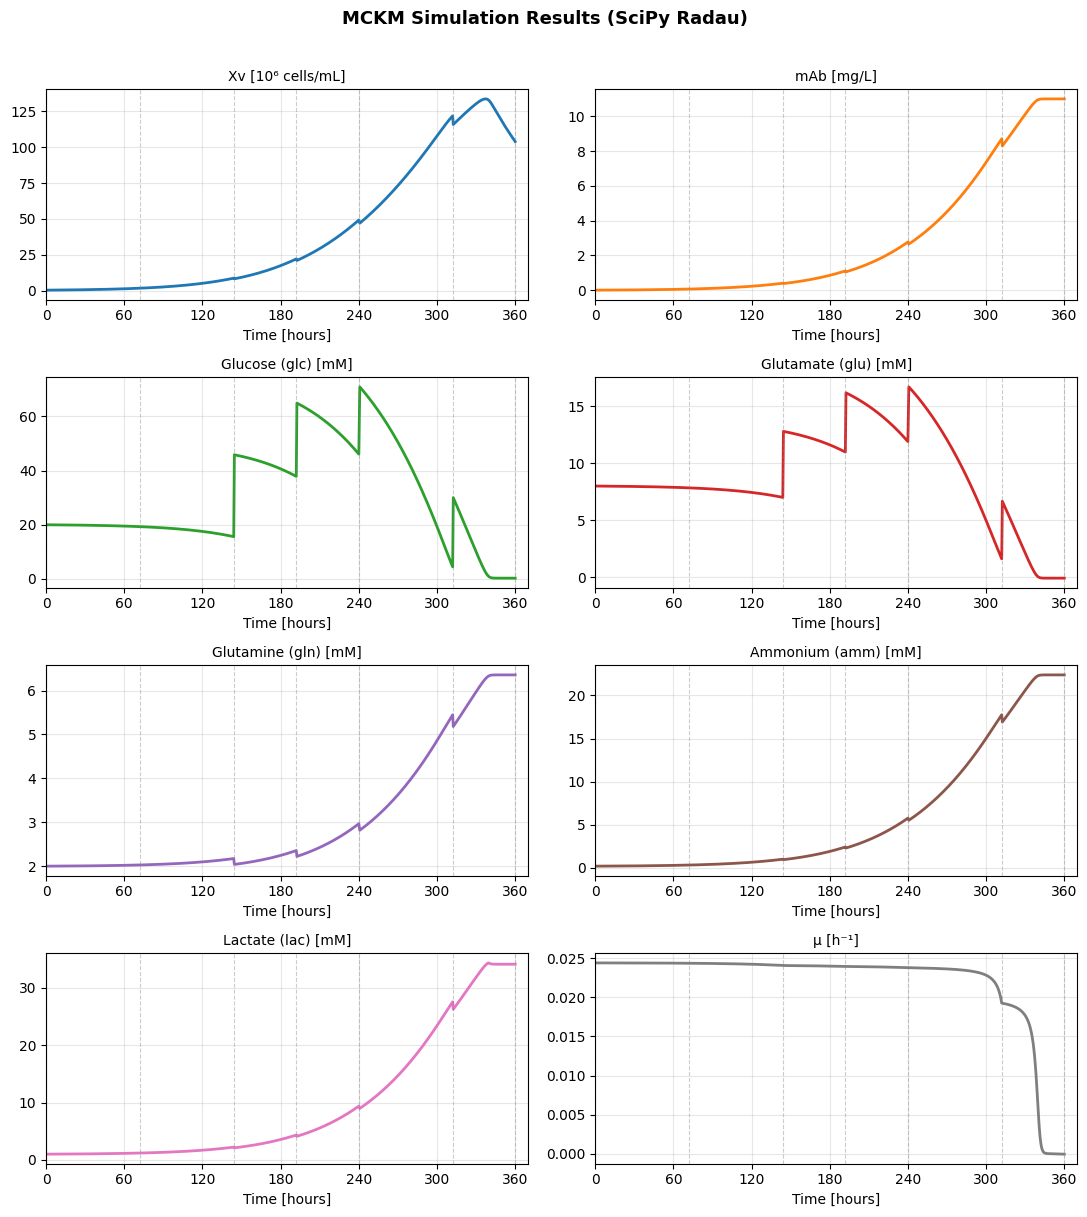

In [ ]:
fig, axs = plt.subplots(4, 2, figsize=(11, 12))
axs = axs.ravel()

series = [Xv, P, glc, glu, gln, amm, lac, mu]
names  = [
    "Xv [10⁶ cells/mL]",
    "mAb [mg/L]",
    "Glucose (glc) [mM]",
    "Glutamate (glu) [mM]",
    "Glutamine (gln) [mM]",
    "Ammonium (amm) [mM]",
    "Lactate (lac) [mM]",
    "μ [h⁻¹]"
]
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red',
          'tab:purple', 'tab:brown', 'tab:pink', 'tab:gray']

for ax, s, name, color in zip(axs, series, names, colors):
    ax.plot(t, s, color=color, linewidth=2)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Time [hours]")
    ax.set_xlim(0, 370) # Slightly extend x-axis limit to ensure 360 is visible
    ax.set_xticks(np.arange(0, 361, 60)) # Ensure 360 is a visible tick
    ax.grid(True, alpha=0.3)
    # Mark sampling times in hours
    for ts in t_samples_h:
        ax.axvline(ts, color='gray', linestyle='--', alpha=0.4, linewidth=0.8)

plt.suptitle("MCKM Simulation Results (SciPy Radau)",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("MCKM_simulacion_horas.png", dpi=150, bbox_inches='tight')
plt.show()

## 6. Comparison of different SciPy solvers

Simulating methods...
Radau : 0.284 s
BDF   : 0.230 s
LSODA : 0.037 s
RK45  : 0.047 s
RK23  : 0.174 s


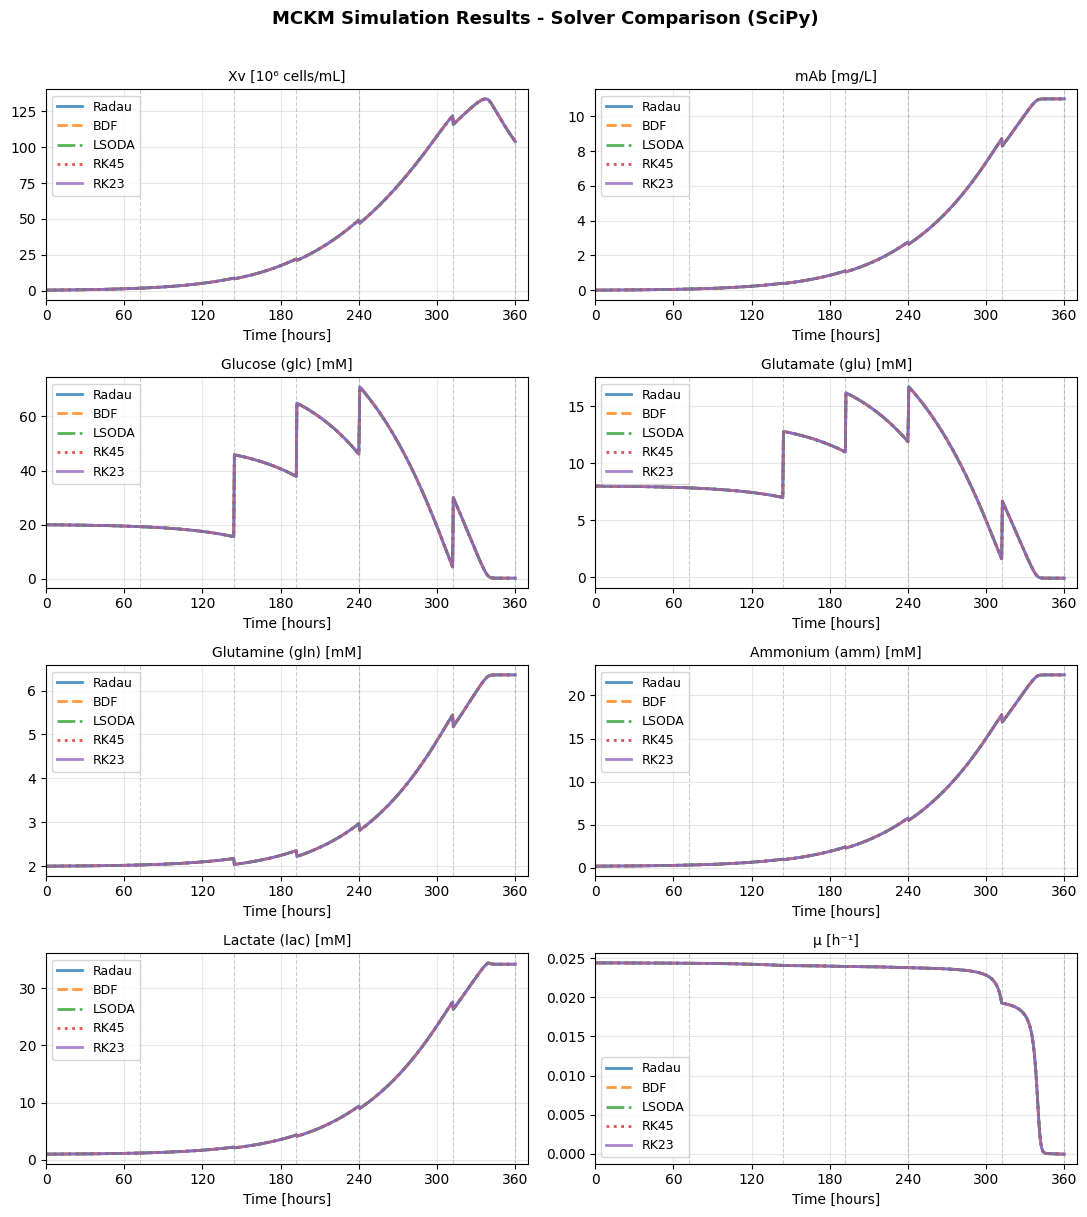

In [ ]:
# Define solvers to evaluate
solvers = ['Radau', 'BDF', 'LSODA', 'RK45', 'RK23']
results_dict = {}

print("Simulating methods...")
for solver in solvers:
    start = time.time()
    t_sol, X_sol = simulate_mckm_fedbatch(
        params=params,
        X0=X0,
        t_samples=t_samples_h, # Use t_samples_h already defined
        V0=V0, # Use V0 already defined
        feed_times=feed_times, # Use feed_times already defined
        feed_volumes=feed_volumes, # Use feed_volumes already defined
        glc_feed=glc_feed, # Use glc_feed already defined
        glu_feed=glu_feed, # Use glu_feed already defined
        method=solver # Pass the solver as a 'method' argument
    )
    elapsed = time.time() - start

    if t_sol is not None:
        results_dict[solver] = (t_sol, X_sol)
        print(f"{solver:<6}: {elapsed:.3f} s")
    else:
        results_dict[solver] = (None, None)
        print(f"{solver:<6}: Failed")

# Generate the original 4x2 plot with multiple curves
# Use t_samples_h directly for vertical lines as requested to be in hours
t_samples_plot_h = t_samples_h

fig, axs = plt.subplots(4, 2, figsize=(11, 12))
axs = axs.ravel()

names  = [
    "Xv [10⁶ cells/mL]", "mAb [mg/L]", "Glucose (glc) [mM]", "Glutamate (glu) [mM]",
    "Glutamine (gln) [mM]", "Ammonium (amm) [mM]", "Lactate (lac) [mM]", "μ [h⁻¹]"
]

# Visual styles to differentiate methods
solver_colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
line_styles = ['-', '--', '-.', ':', '-']

for i in range(8): # Iterate over the 8 state variables
    ax = axs[i]
    ax.set_title(names[i], fontsize=10)
    ax.set_xlabel("Time [hours]") # Change x-axis label to hours
    ax.set_xlim(0, 370) # Slightly extend x-axis limit to ensure 360 is visible
    ax.set_xticks(np.arange(0, 361, 60)) # Ensure 360 is a visible tick
    ax.grid(True, alpha=0.3)

    # Mark sampling times
    for ts in t_samples_plot_h:
        ax.axvline(ts, color='gray', linestyle='--', alpha=0.4, linewidth=0.8)

    # Plot each solver
    for (solver, color, ls) in zip(solvers, solver_colors, line_styles):
        t_sol, X_sol = results_dict[solver]
        if t_sol is not None:
            # Plot with time in hours directly
            ax.plot(t_sol, X_sol[:, i], color=color, linestyle=ls, linewidth=2, alpha=0.8, label=solver)

    # Legend in each plot
    ax.legend(loc='best', fontsize=9)

plt.suptitle("MCKM Simulation Results - Solver Comparison (SciPy)", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 7. Visualization using Casadi/IDAS

In [ ]:
def solve_with_casadi_idas(params, X0, t_samples, V0, feed_times, feed_volumes, glc_feed, glu_feed):
    # Define symbolic variables
    t = ca.MX.sym('t')
    # State: [Xv, P, glc, glu, gln, amm, lac, mu] (8 states)
    x = ca.MX.sym('x', 8)

    # Unpack symbolic states (8 elements)
    Xv, P, glc, glu, gln, amm, lac, mu = x[0], x[1], x[2], x[3], x[4], x[5], x[6], x[7]

    # Define model equations (RHS)
    # These are identical to mckm_batch_rhs
    mu_d = params['kD'] * amm / (params['KD_amm'] + amm)
    qP = mu * params['Y_PX']
    qglc = mu / params['Y_X_glc'] + params['m_glc']
    qglu = mu / params['Y_X_glu']
    qgln = mu / params['Y_X_gln']
    qamm = mu / params['Y_X_amm']

    # Lactate switch using ca.if_else (equivalent to if glc > alpha_glc)
    qlac = ca.if_else(glc > params['alpha_glc'],
                      params['Y_lac_glc'] * qglc,
                      -mu / params['Y_X_lac'] + params['Y_lac_glc'] * qglc)

    # ODEs for the 8 states
    dXv_dt = (mu - mu_d) * Xv
    dP_dt  = qP * Xv
    dglc_dt = -qglc * Xv
    dglu_dt = -qglu * Xv
    dgln_dt = -qgln * Xv + params['Y_gln_glu'] * qglu * Xv
    damm_dt = qamm * Xv
    dlac_dt = qlac * Xv
    dmu_dt  = params['mu_max'] * params['K_glc'] / (params['K_glc'] + glc)**2 * dglc_dt

    rhs = ca.vertcat(dXv_dt, dP_dt, dglc_dt, dglu_dt, dgln_dt, damm_dt, dlac_dt, dmu_dt)

    # Configure IDAS integrator
    ode = {'x': x, 'p': ca.MX(), 't': t, 'ode': rhs}
    opts = {'abstol': 1e-9, 'reltol': 1e-7}

    all_t = [t_samples[0]]
    X_current = np.array(X0, dtype=float)
    V_current = float(V0)

    # Store 8 states + volume
    all_X = [np.hstack((X_current, V_current))]

    bolus_map = {idx: vol for idx, vol in zip(feed_times, feed_volumes)}

    # Fed-batch simulation by intervals (Same logic as simulate_mckm_fedbatch)
    for i in range(len(t_samples) - 1):
        t0 = t_samples[i]
        tf = t_samples[i+1]

        # Apply Bolus at the start of the interval (if applicable)
        if i in bolus_map:
            V_feed_i = bolus_map[i]
            V_before = V_current
            V_after = V_before + V_feed_i
            f = V_before / V_after

            X_new = X_current.copy()
            X_new[2] = (X_current[2] * V_before + glc_feed * V_feed_i) / V_after # glc
            X_new[3] = (X_current[3] * V_before + glu_feed * V_feed_i) / V_after # glu
            # Concentration dilution
            for j in [0, 1, 4, 5, 6]:
                X_new[j] *= f

            X_current = X_new
            V_current = V_after

        # Integrator
        I = ca.integrator('I', 'idas', ode, t0, tf, opts)
        res = I(x0=X_current)
        X_current = np.array(res['xf']).flatten()

        all_t.append(tf)
        all_X.append(np.hstack((X_current, V_current)))

    return np.array(all_t), np.array(all_X)

# Run simulation with the same parameters and initial conditions
start_time_casadi = time.time()
t_ca, X_ca = solve_with_casadi_idas(
    params, X0, t_samples_h, V0, feed_times, feed_volumes, glc_feed, glu_feed
)
end_time_casadi = time.time()
elapsed_time_casadi = end_time_casadi - start_time_casadi

print("Simulation with CasADi IDAS completed.")
print(f"Execution time with CasADi IDAS: {elapsed_time_casadi:.3f} seconds")
print(f"Final Comparison (CasADi vs SciPy):")
print(f"  Xv: {X_ca[-1, 0]:.3f} vs 103.982")
print(f"  mAb: {X_ca[-1, 1]:.3f} vs 10.999")

Simulation with CasADi IDAS completed.
Execution time with CasADi IDAS: 0.056 seconds
Final Comparison (CasADi vs SciPy):
  Xv: 103.974 vs 103.982
  mAb: 10.999 vs 10.999


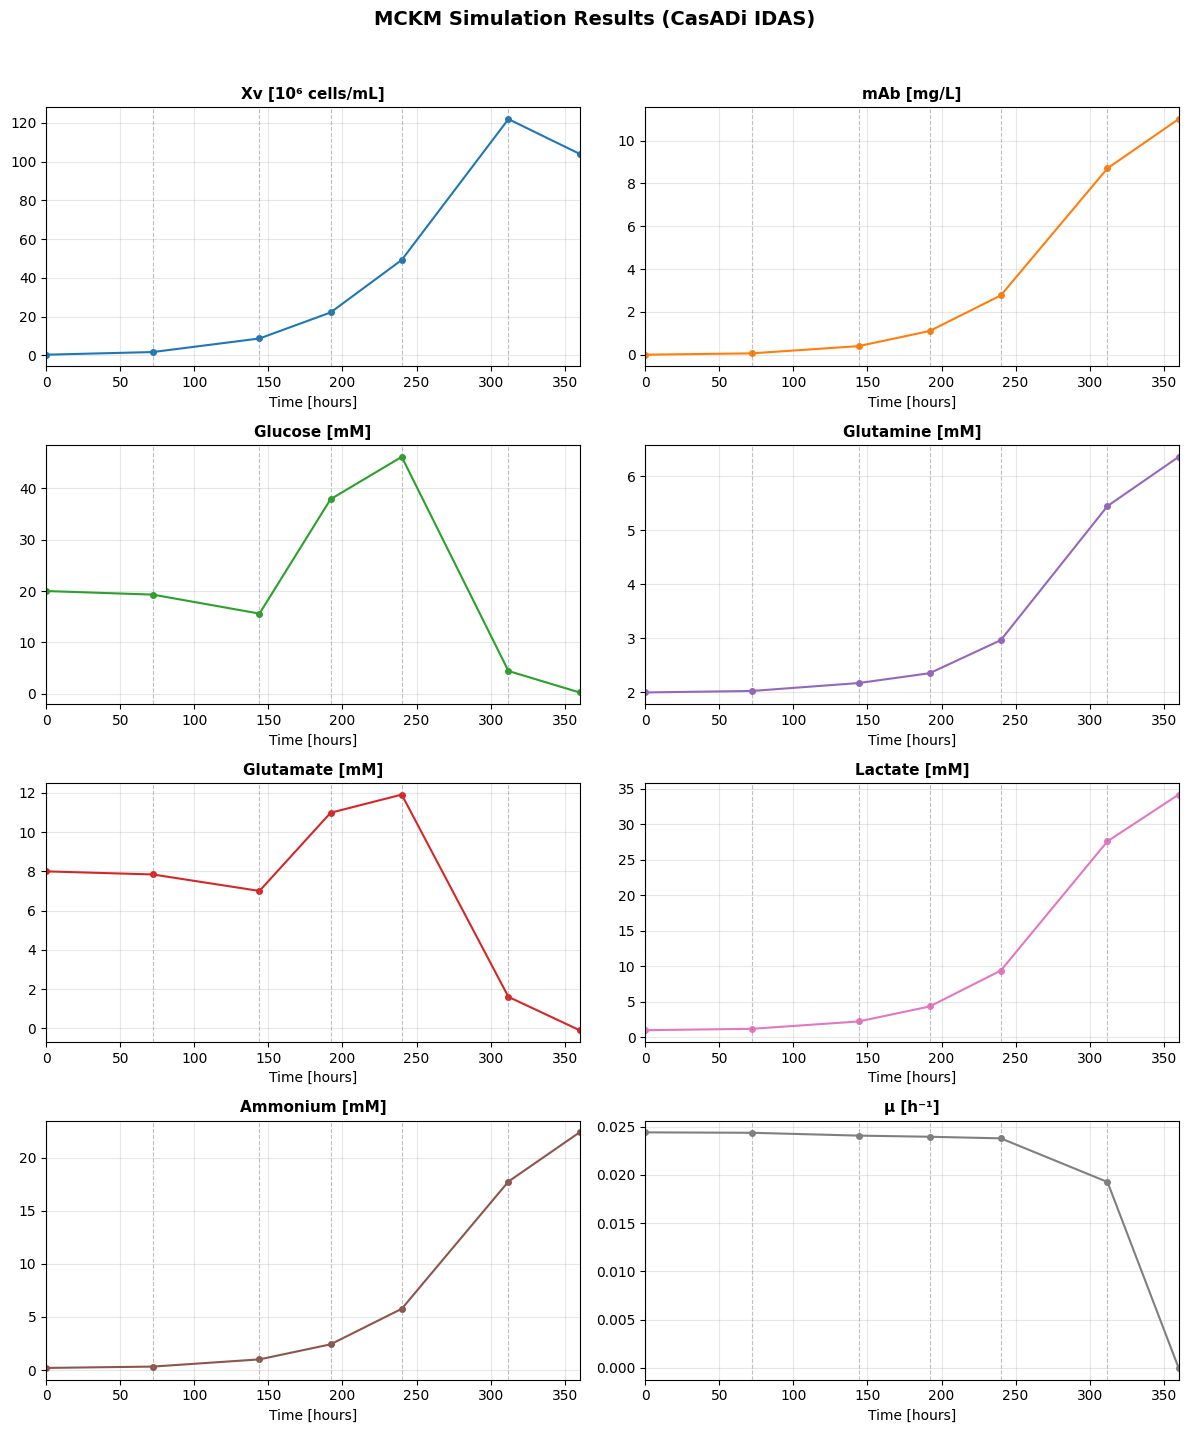

In [ ]:
# Use time in hours directly for the X-axis
t_ca_plot = t_ca

# Configure the figure with subplots for each state variable
fig, axs = plt.subplots(4, 2, figsize=(12, 14))
axs = axs.ravel()

# Names and units of variables (original order)
original_labels = [
    "Xv [10⁶ cells/mL]", "mAb [mg/L]", "Glucose [mM]", "Glutamate [mM]",
    "Glutamine [mM]", "Ammonium [mM]", "Lactate [mM]", "μ [h⁻¹]"
]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']

# Define the new plotting order by index from the original_labels list
# Requested order: 1,1 biomass; 1,2 protein; 2,1 glucose; 2,2 glutamine; 3,1 glutamate; 3,2 lactate; 4,1 ammonium; 4,2 mu
plot_order_indices = [
    0, # Xv (biomass)
    1, # mAb (protein)
    2, # Glucose
    4, # Glutamine
    3, # Glutamate
    6, # Lactate
    5, # Ammonium
    7  # mu
]

for i, original_idx in enumerate(plot_order_indices):
    # Use the original_idx to get the correct data and label from the original arrays
    axs[i].plot(t_ca_plot, X_ca[:, original_idx], 'o-', color=colors[original_idx], markersize=4, linewidth=1.5, label='CasADi IDAS')
    axs[i].set_title(original_labels[original_idx], fontsize=11, fontweight='bold')
    axs[i].set_xlabel("Time [hours]")
    axs[i].set_xlim(0, 360)
    axs[i].grid(True, alpha=0.3)

    # Highlight sampling/feeding moments in hours
    for ts in t_samples_h:
        axs[i].axvline(ts, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)

plt.suptitle("MCKM Simulation Results (CasADi IDAS)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Although the curves are not smoothed, the behavior is similar compared to Sietaram et al. and the literature.

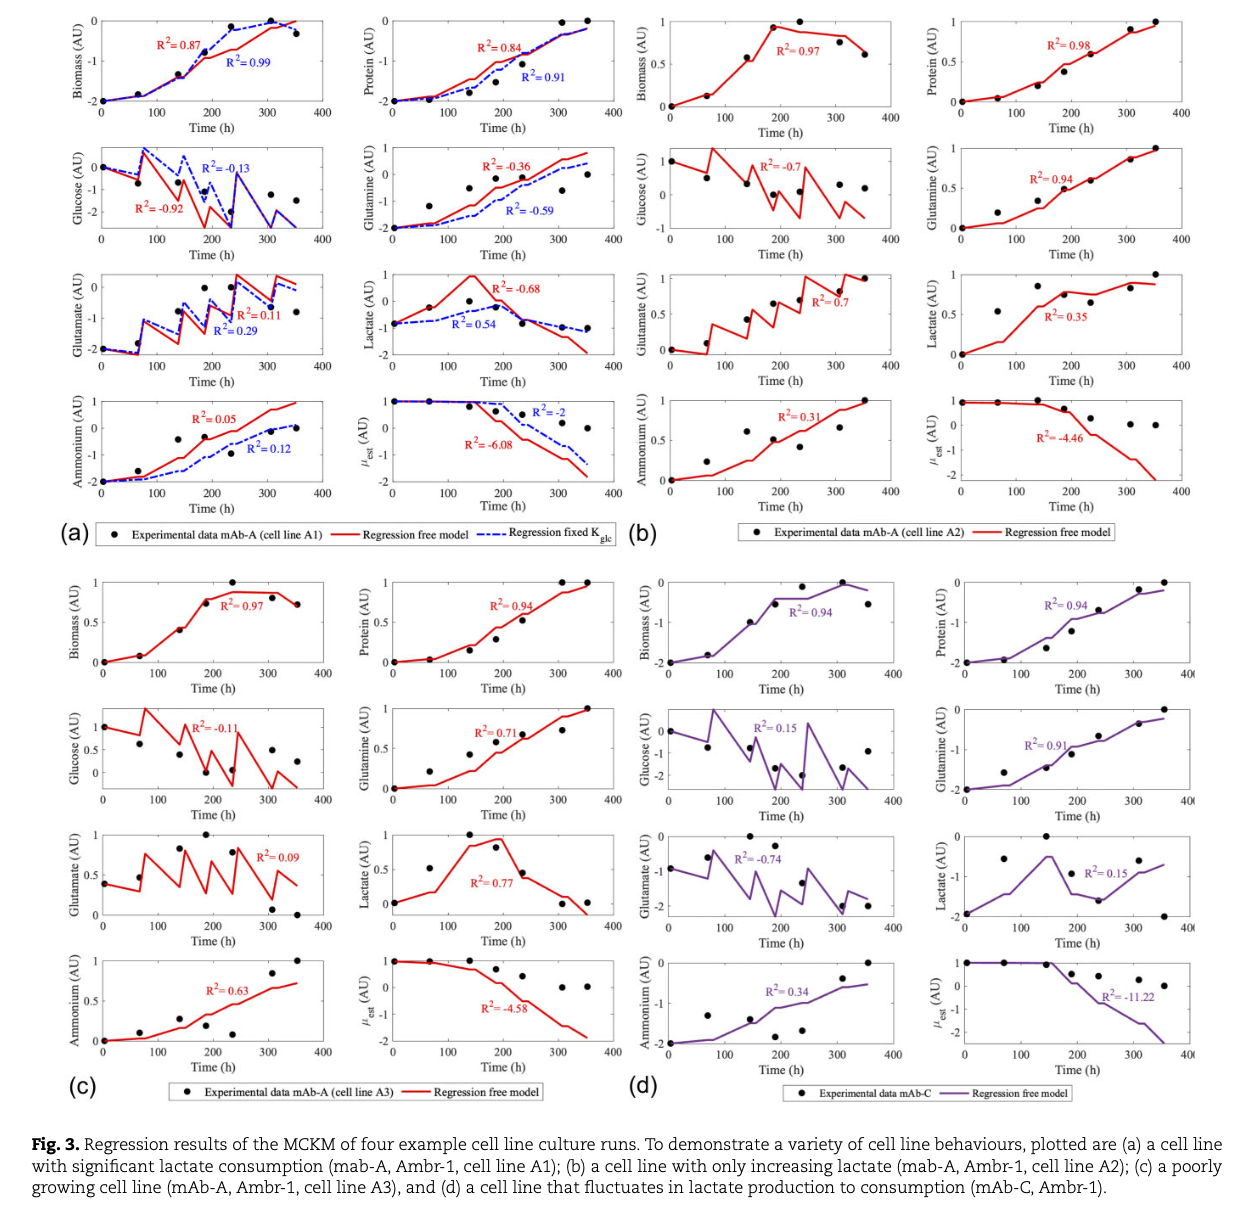


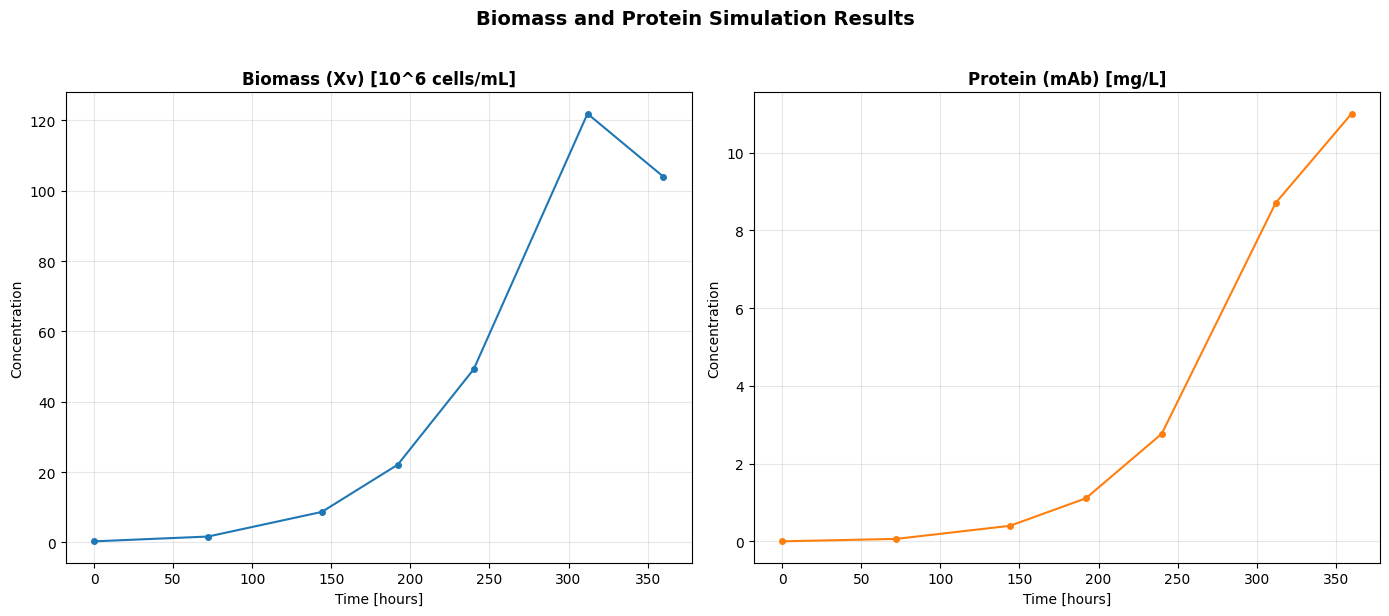

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Biomass plot (Xv is at index 0 in X_ca)
axs[0].plot(t_ca, X_ca[:, 0], 'o-', color='#1f77b4', markersize=4, linewidth=1.5)
axs[0].set_title('Biomass (Xv) [10^6 cells/mL]', fontsize=12, fontweight='bold')
axs[0].set_xlabel('Time [hours]')
axs[0].set_ylabel('Concentration')
axs[0].grid(True, alpha=0.3)

# Protein plot (mAb is at index 1 in X_ca)
axs[1].plot(t_ca, X_ca[:, 1], 'o-', color='#ff7f0e', markersize=4, linewidth=1.5)
axs[1].set_title('Protein (mAb) [mg/L]', fontsize=12, fontweight='bold')
axs[1].set_xlabel('Time [hours]')
axs[1].set_ylabel('Concentration')
axs[1].grid(True, alpha=0.3)

plt.suptitle('Biomass and Protein Simulation Results', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In the MCKM model, Xv and mAb are the most important variables to evaluate, so this graph obtained by solving the ODEs is the most important and comparative.

### 7. Comparison: SciPy (`solve_ivp`) vs CasADi (`IDAS`)

The following section analyzes the technical differences and numerical results of both approaches.

In [ ]:
# Extract final values
final_scipy = X[-1, :]
final_casadi = X_ca[-1, :8] # We exclude volume from the state comparison

# Create comparative table
estados = ["Xv", "mAb", "glc", "glu", "gln", "amm", "lac", "mu"]
df_comp = pd.DataFrame({
    'Variable': estados,
    'SciPy (Radau)': final_scipy,
    'CasADi (IDAS)': final_casadi
})

df_comp['Absolute Diff'] = np.abs(df_comp['SciPy (Radau)'] - df_comp['CasADi (IDAS)'])
df_comp['Relative Diff (%)'] = (df_comp['Absolute Diff'] / np.abs(df_comp['SciPy (Radau)'])) * 100

display(df_comp.round(6))

,Variable,SciPy (Radau),CasADi (IDAS),Absolute Diff,Relative Diff (%)
0,Xv,103.981818,103.974453,0.007365,0.007083
1,mAb,10.999238,10.998886,0.000352,0.003204
2,glc,0.286485,0.290354,0.003868,1.350303
3,glu,-0.095344,-0.094464,0.000880,0.922993
4,gln,6.357134,6.356981,0.000153,0.002408
5,amm,22.378577,22.377865,0.000712,0.003182
6,lac,34.150330,34.151697,0.001367,0.004002
7,mu,-0.000064,-0.000006,0.000058,90.098181


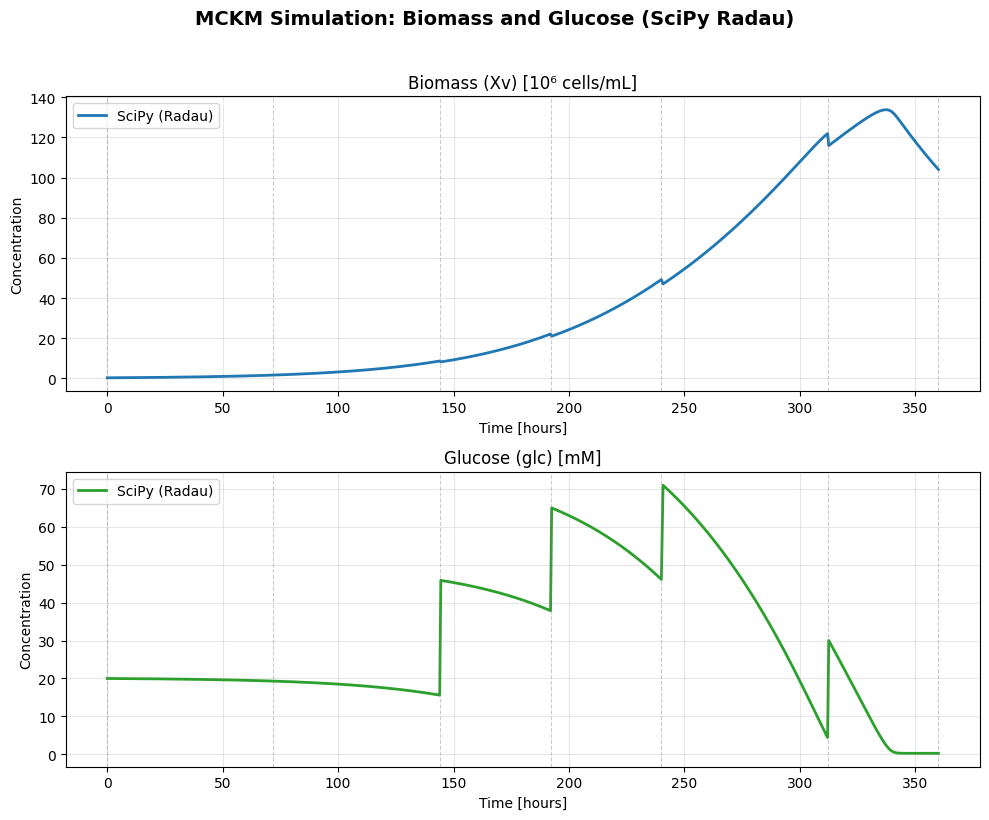

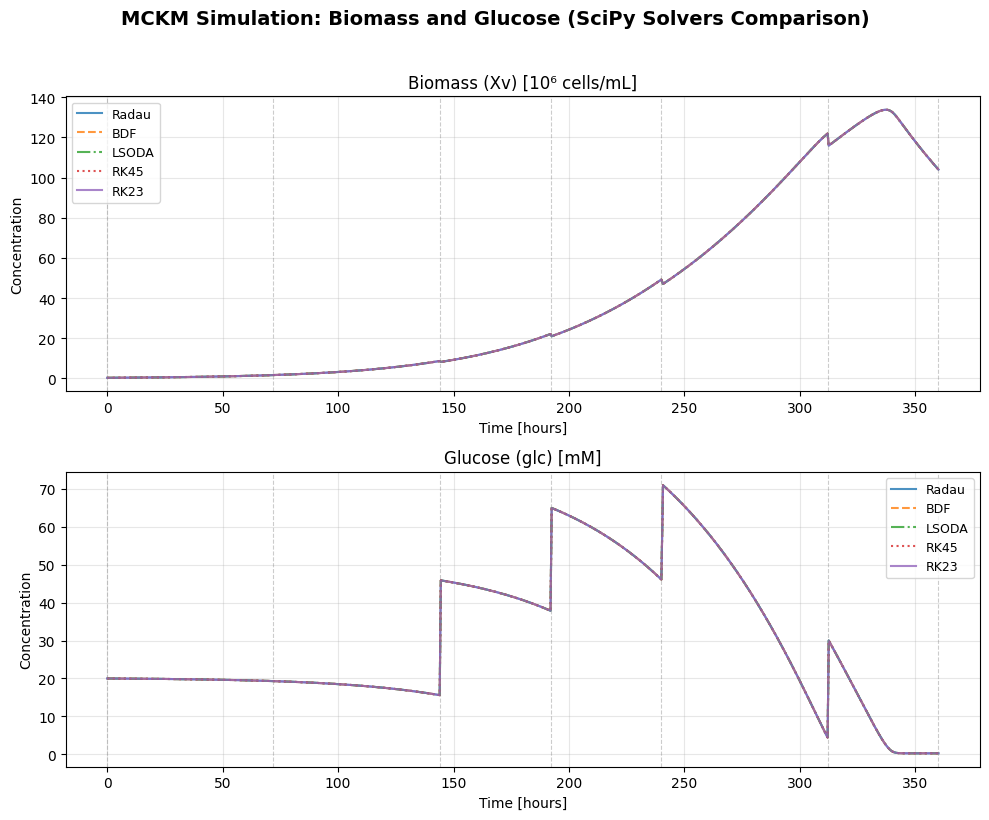

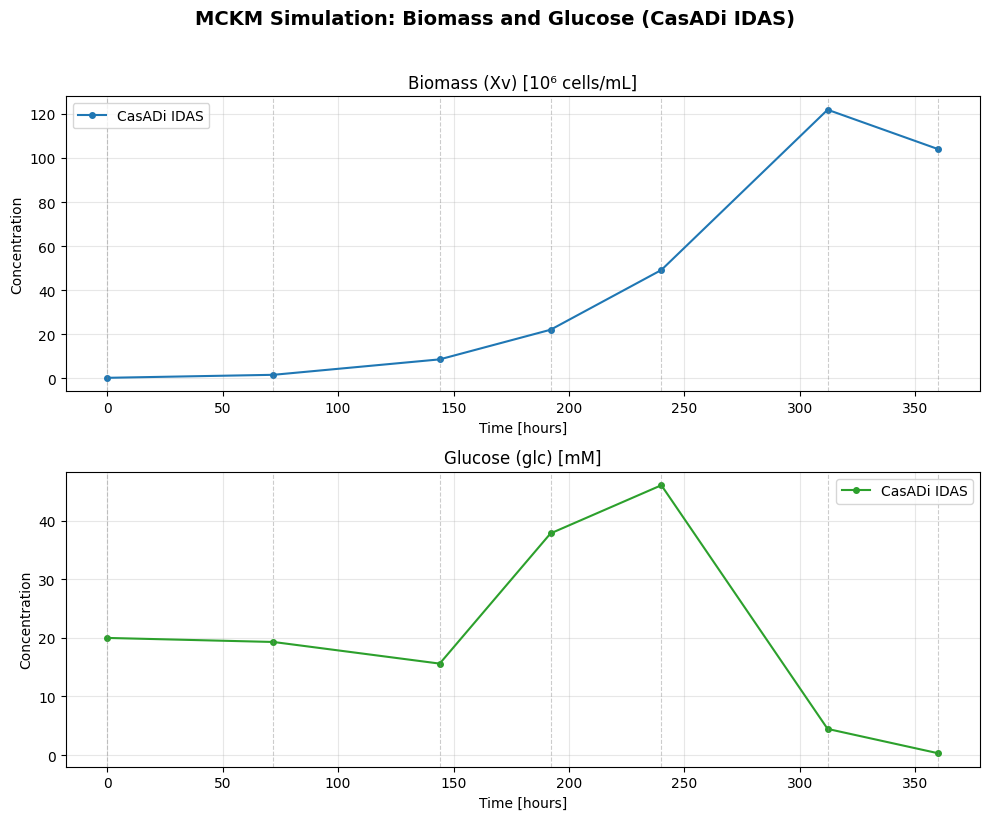

In [ ]:
# SciPy Radau
t_radau, X_radau = results_dict['Radau']
Xv_radau = X_radau[:, 0] # Biomass
glc_radau = X_radau[:, 2] # Glucose

# All SciPy solvers
solvers = ['Radau', 'BDF', 'LSODA', 'RK45', 'RK23']
solver_colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
line_styles = ['-', '--', '-.', ':', '-']

# CasADi
t_casadi = t_ca # CasADi time
Xv_casadi = X_ca[:, 0] # Biomass
glc_casadi = X_ca[:, 2] # Glucose

# Labels for plots
labels = {
    0: "Biomass (Xv) [10⁶ cells/mL]",
    2: "Glucose (glc) [mM]"
}

# SciPy (Radau) Plot for Biomass and Glucose
fig1, axs1 = plt.subplots(2, 1, figsize=(10, 8)) # Changed to 2 rows, 1 column

# Biomass
axs1[0].plot(t_radau, Xv_radau, color='tab:blue', linewidth=2, label='SciPy (Radau)')
axs1[0].set_title(labels[0], fontsize=12)
axs1[0].set_xlabel("Time [hours]")
axs1[0].set_ylabel("Concentration")
axs1[0].grid(True, alpha=0.3)
axs1[0].legend()
for ts in t_samples_h:
    axs1[0].axvline(ts, color='gray', linestyle='--', alpha=0.4, linewidth=0.8)

# Glucose
axs1[1].plot(t_radau, glc_radau, color='tab:green', linewidth=2, label='SciPy (Radau)')
axs1[1].set_title(labels[2], fontsize=12)
axs1[1].set_xlabel("Time [hours]")
axs1[1].set_ylabel("Concentration")
axs1[1].grid(True, alpha=0.3)
axs1[1].legend()
for ts in t_samples_h:
    axs1[1].axvline(ts, color='gray', linestyle='--', alpha=0.4, linewidth=0.8)

plt.suptitle("MCKM Simulation: Biomass and Glucose (SciPy Radau)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Plot of all SciPy methods for Biomass and Glucose
fig2, axs2 = plt.subplots(2, 1, figsize=(10, 8)) # Changed to 2 rows, 1 column

# Biomass
for (solver, color, ls) in zip(solvers, solver_colors, line_styles):
    t_sol, X_sol = results_dict[solver]
    if t_sol is not None:
        axs2[0].plot(t_sol, X_sol[:, 0], color=color, linestyle=ls, linewidth=1.5, alpha=0.8, label=solver)
axs2[0].set_title(labels[0], fontsize=12)
axs2[0].set_xlabel("Time [hours]")
axs2[0].set_ylabel("Concentration")
axs2[0].grid(True, alpha=0.3)
axs2[0].legend(loc='best', fontsize=9)
for ts in t_samples_h:
    axs2[0].axvline(ts, color='gray', linestyle='--', alpha=0.4, linewidth=0.8)

# Glucose
for (solver, color, ls) in zip(solvers, solver_colors, line_styles):
    t_sol, X_sol = results_dict[solver]
    if t_sol is not None:
        axs2[1].plot(t_sol, X_sol[:, 2], color=color, linestyle=ls, linewidth=1.5, alpha=0.8, label=solver)
axs2[1].set_title(labels[2], fontsize=12)
axs2[1].set_xlabel("Time [hours]")
axs2[1].set_ylabel("Concentration")
axs2[1].grid(True, alpha=0.3)
axs2[1].legend(loc='best', fontsize=9)
for ts in t_samples_h:
    axs2[1].axvline(ts, color='gray', linestyle='--', alpha=0.4, linewidth=0.8)

plt.suptitle("MCKM Simulation: Biomass and Glucose (SciPy Solvers Comparison)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# CasADi Plot for Biomass and Glucose
fig3, axs3 = plt.subplots(2, 1, figsize=(10, 8)) # Changed to 2 rows, 1 column

# Biomass
axs3[0].plot(t_casadi, Xv_casadi, 'o-', color='#1f77b4', markersize=4, linewidth=1.5, label='CasADi IDAS')
axs3[0].set_title(labels[0], fontsize=12)
axs3[0].set_xlabel("Time [hours]")
axs3[0].set_ylabel("Concentration")
axs3[0].grid(True, alpha=0.3)
axs3[0].legend()
for ts in t_samples_h:
    axs3[0].axvline(ts, color='gray', linestyle='--', alpha=0.4, linewidth=0.8)

# Glucose
axs3[1].plot(t_casadi, glc_casadi, 'o-', color='#2ca02c', markersize=4, linewidth=1.5, label='CasADi IDAS')
axs3[1].set_title(labels[2], fontsize=12)
axs3[1].set_xlabel("Time [hours]")
axs3[1].set_ylabel("Concentration")
axs3[1].grid(True, alpha=0.3)
axs3[1].legend()
for ts in t_samples_h:
    axs3[1].axvline(ts, color='gray', linestyle='--', alpha=0.4, linewidth=0.8)

plt.suptitle("MCKM Simulation: Biomass and Glucose (CasADi IDAS)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Other metabolites were evaluated to visualize the differences between solvers and with the paper Sietaram et al.

## 8. Estructural Identifiability Analysis

In [ ]:
def perform_structural_identifiability_analysis(params, X0, t_samples, V0, feed_times, feed_volumes, glc_feed, glu_feed):
    print("\nStarting SVD-ROSM Structural Identifiability Analysis")

    # Define symbolic state variables and parameters
    x = ca.MX.sym('x', 8)  # [Xv, P, glc, glu, gln, amm, lac, mu]
    p_sym = ca.MX.sym('p', 13) # The 13 parameters to analyze

    Xv, P, glc, glu, gln, amm, lac, mu = x[0], x[1], x[2], x[3], x[4], x[5], x[6], x[7]

    # Parameter mapping to maintain order (order of the 13 parameters)
    p_names = ['mu_max', 'kD', 'K_glc', 'Y_X_glc', 'Y_X_gln', 'Y_X_glu', 'Y_X_amm',
               'Y_lac_glc', 'Y_gln_glu', 'Y_X_lac', 'Y_PX', 'm_glc', 'KD_amm']

    # Symbolic variable assignment
    mu_max, kD, K_glc, Y_X_glc, Y_X_gln, Y_X_glu, Y_X_amm = p_sym[0], p_sym[1], p_sym[2], p_sym[3], p_sym[4], p_sym[5], p_sym[6]
    Y_lac_glc, Y_gln_glu, Y_X_lac, Y_PX, m_glc, KD_amm = p_sym[7], p_sym[8], p_sym[9], p_sym[10], p_sym[11], p_sym[12]

    # Global constant
    alpha_glc = params['alpha_glc']

    # Model equations (Symbolic RHS)
    mu_d = kD * amm / (KD_amm + amm)
    qP = mu * Y_PX
    qglc = mu / Y_X_glc + m_glc
    qglu = mu / Y_X_glu
    qgln = mu / Y_X_gln
    qamm = mu / Y_X_amm

    # Lactate switch
    qlac = ca.if_else(glc > alpha_glc,
                      Y_lac_glc * qglc,
                      -mu / Y_X_lac + Y_lac_glc * qglc)

    # ODEs
    dXv_dt = (mu - mu_d) * Xv
    dP_dt  = qP * Xv
    dglc_dt = -qglc * Xv
    dglu_dt = -qglu * Xv
    dgln_dt = -qgln * Xv + Y_gln_glu * qglu * Xv
    damm_dt = qamm * Xv
    dlac_dt = qlac * Xv
    dmu_dt  = mu_max * K_glc / (K_glc + glc)**2 * dglc_dt

    rhs = ca.vertcat(dXv_dt, dP_dt, dglc_dt, dglu_dt, dgln_dt, damm_dt, dlac_dt, dmu_dt)

    # Configure Forward Sensitivities (S Matrix)
    # Calculate the Jacobian of states with respect to parameters
    ode = {'x': x, 'p': p_sym, 'ode': rhs}

    # Create an integrator that also calculates 'forward' sensitivities
    # 'idas' in CasADi automatically calculates sensitivities if requested
    opts = {'abstol': 1e-9, 'reltol': 1e-7}

    # Numerical values of parameters in the defined order
    p_num = [params[name] for name in p_names]

    # Store states and raw sensitivity matrix at each t_sample
    # Dimensions: 7 times x 7 observable outputs (ignoring mu_est as an observable output)
    # Total rows: 49. Columns: 13 parameters.
    S_raw = np.zeros((len(t_samples) * 7, 13))
    Y_out = np.zeros((len(t_samples) * 7))

    X_current = np.array(X0, dtype=float)
    V_current = float(V0)

    bolus_map = {idx: vol for idx, vol in zip(feed_times, feed_volumes)}

    # Evaluate at t=0 (Initial condition, sensitivities here are usually 0)
    # Assuming initial states are independent of kinetic parameters
    row_idx = 0
    Y_out[row_idx:row_idx+7] = X_current[0:7]
    row_idx += 7

    # Integration and sensitivity extraction
    for i in range(len(t_samples) - 1):
        t0 = t_samples[i]
        tf = t_samples[i+1]

        # Bolus feed
        if i in bolus_map:
            V_feed_i = bolus_map[i]
            V_before = V_current
            V_after = V_before + V_feed_i
            f = V_before / V_after

            X_new = X_current.copy()
            X_new[2] = (X_current[2] * V_before + glc_feed * V_feed_i) / V_after # glc
            X_new[3] = (X_current[3] * V_before + glu_feed * V_feed_i) / V_after # glu
            for j in [0, 1, 4, 5, 6]:
                X_new[j] *= f

            X_current = X_new
            V_current = V_after

        # Build integrator supporting forward sensitivity
        I = ca.integrator('I', 'idas', ode, t0, tf, opts)

        # Obtain dx/dp at the end of the interval using CasADi jacobian
        I_func = I(x0=x, p=p_sym)
        xf_sym = I_func['xf']

        # Calculate Jacobian matrix (8 states x 13 parameters)
        jac_sym = ca.jacobian(xf_sym, p_sym)

        # Numerical evaluation
        eval_func = ca.Function('eval_func', [x, p_sym], [xf_sym, jac_sym])
        xf_num, J_num = eval_func(X_current, p_num)

        X_current = np.array(xf_num).flatten()

        # Extract only the 7 observable outputs (omitting state 8 'mu')
        # and save in the corresponding row of S_raw
        S_raw[row_idx:row_idx+7, :] = np.array(J_num)[0:7, :]
        Y_out[row_idx:row_idx+7] = X_current[0:7]

        row_idx += 7

    # Normalization to build ROSM (S_tilde)
    S_tilde = np.zeros_like(S_raw)
    for i in range(49): # 49 rows (7 observable states x 7 time points)
        for j in range(13): # 13 parameters
            # Avoid division by zero if Y_out is 0
            if abs(Y_out[i]) > 1e-12:
                S_tilde[i, j] = S_raw[i, j] * (p_num[j] / abs(Y_out[i]))
            else:
                S_tilde[i, j] = 0.0

    # Singular Value Decomposition (SVD)
    # Using SciPy linalg for SVD
    U, Sigma, Vt = la.svd(S_tilde, full_matrices=False)

    print("Singular Values calculated successfully.")

    return S_tilde, Sigma, Vt, p_names

*Execution*

In [ ]:
S_tilde, Sigma, Vt, p_names = perform_structural_identifiability_analysis(
    params, X0, t_samples_h, V0, feed_times, feed_volumes, glc_feed, glu_feed
)

# Quick Null Space Analysis
print("\nNull Space Analysis (Singular Vectors V^T)")
# Identify parameters that dominate the singular vector associated with the smallest singular value
lowest_sigma_idx = len(Sigma) - 1
vector_nulo = Vt[lowest_sigma_idx, :]

print(f"The smallest singular value is: {Sigma[lowest_sigma_idx]:.2e}")
print("Parameter weights in this singular vector (problematic linear combination):")
for name, weight in zip(p_names, vector_nulo):
    print(f"  {name:<10}: {weight:+.4f}")


Starting SVD-ROSM Structural Identifiability Analysis
Singular Values calculated successfully.

Null Space Analysis (Singular Vectors V^T)
The smallest singular value is: 1.08e-15
Parameter weights in this singular vector (problematic linear combination):
  mu_max    : -0.0000
  kD        : -0.0000
  K_glc     : +0.0000
  Y_X_glc   : -0.0000
  Y_X_gln   : -0.8791
  Y_X_glu   : -0.0000
  Y_X_amm   : +0.0000
  Y_lac_glc : -0.0000
  Y_gln_glu : +0.4766
  Y_X_lac   : +0.0000
  Y_PX      : +0.0000
  m_glc     : +0.0000
  KD_amm    : -0.0000


Graphing Singular Values ​​(Logarithmic Scale)

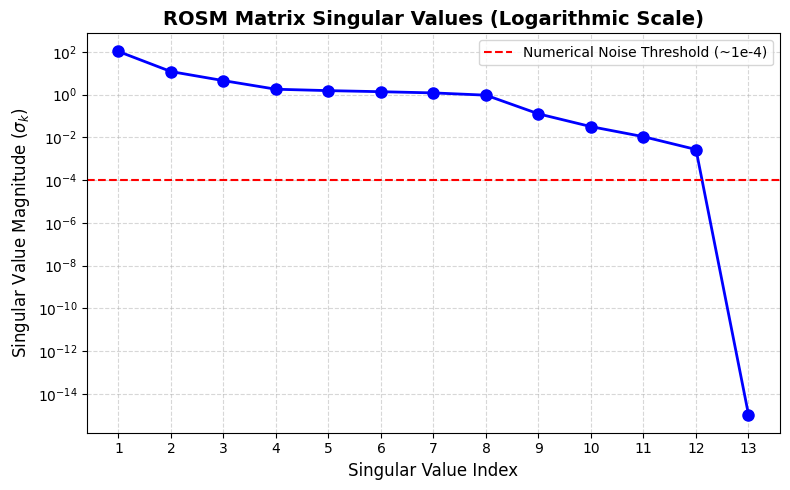

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(Sigma) + 1), Sigma, 'bo-', linewidth=2, markersize=8)
plt.yscale('log')
plt.axhline(y=1e-4, color='r', linestyle='--', label='Numerical Noise Threshold (~1e-4)')
plt.title('ROSM Matrix Singular Values (Logarithmic Scale)', fontsize=14, fontweight='bold')
plt.xlabel('Singular Value Index', fontsize=12)
plt.ylabel('Singular Value Magnitude ($\\sigma_k$)', fontsize=12)
plt.xticks(range(1, 14))
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

SVD-ROOM analysis shows that the singular value $\sigma_{13}$ is below the allowed threshold, indicating that there are collinear parameters and the current 13-parameter model is structurally unidentifiable.

## 9. Monte Carlo analysis to evaluate the robustness of SVD-ROOM


Starting Monte Carlo SVD-ROSM Analysis
Evaluating 100 parameter sets...
  Progress: 10/100 iterations complete.
  Progress: 20/100 iterations complete.
  Progress: 30/100 iterations complete.
  Progress: 40/100 iterations complete.
  Progress: 50/100 iterations complete.
  Progress: 60/100 iterations complete.
  Progress: 70/100 iterations complete.
  Progress: 80/100 iterations complete.
  Progress: 90/100 iterations complete.
  Progress: 100/100 iterations complete.
Monte Carlo simulations completed.


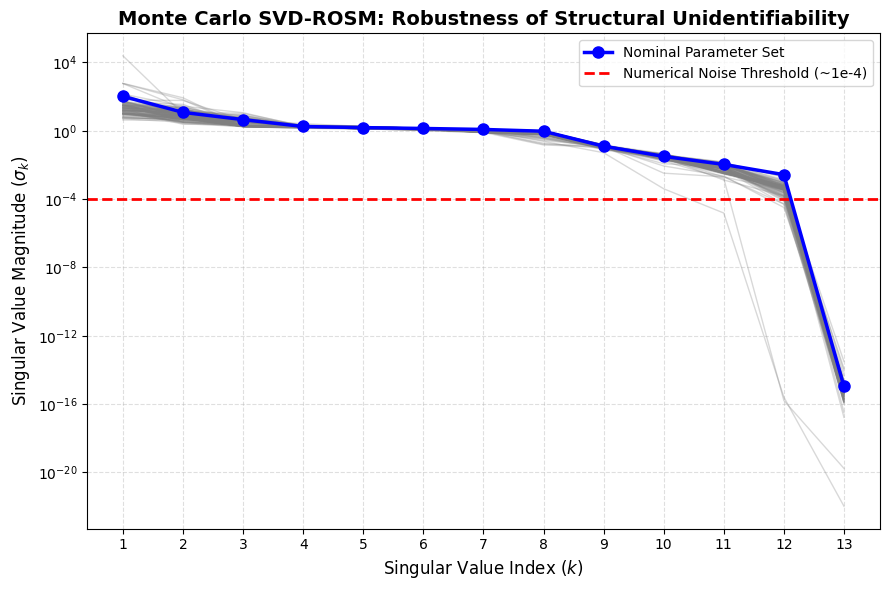

In [ ]:
print("\nStarting Monte Carlo SVD-ROSM Analysis")

# Define parameter names in order
p_names = ['mu_max', 'kD', 'K_glc', 'Y_X_glc', 'Y_X_gln', 'Y_X_glu', 'Y_X_amm',
           'Y_lac_glc', 'Y_gln_glu', 'Y_X_lac', 'Y_PX', 'm_glc', 'KD_amm']

# Extract nominal values from the original 'params' dictionary
theta_nom = np.array([params[name] for name in p_names])

# Monte Carlo Configuration
NExp = 100
theta_low = 0.8 * theta_nom
theta_high = 1.2 * theta_nom
np.random.seed(42)

# Generate the matrix of random parameters
THETA = np.random.uniform(theta_low, theta_high, size=(NExp, len(p_names)))
THETA[0] = theta_nom

all_sigmas = np.zeros((NExp, 13))

print(f"Evaluating {NExp} parameter sets...")

# Monte Carlo Loop
for exp_idx in range(NExp):
    current_params = params.copy()
    for j, name in enumerate(p_names):
        current_params[name] = THETA[exp_idx, j]

    # Suppress internal prints of the function to avoid truncation/clutter
    with contextlib.redirect_stdout(open(os.devnull, 'w')):
        S_tilde_mc, Sigma_mc, _, _ = perform_structural_identifiability_analysis(
            current_params, X0, t_samples_h, V0, feed_times, feed_volumes, glc_feed, glu_feed
        )

    all_sigmas[exp_idx, :] = Sigma_mc
    if (exp_idx + 1) % 10 == 0:
        print(f"  Progress: {exp_idx + 1}/{NExp} iterations complete.")

print("Monte Carlo simulations completed.")

# 6. Visualization
plt.figure(figsize=(9, 6))
for exp_idx in range(NExp):
    if exp_idx == 0:
        plt.plot(range(1, 14), all_sigmas[exp_idx, :], 'bo-', linewidth=2.5, markersize=8, label='Nominal Parameter Set', zorder=10)
    else:
        plt.plot(range(1, 14), all_sigmas[exp_idx, :], color='gray', alpha=0.3, linewidth=1)

plt.yscale('log')
plt.axhline(y=1e-4, color='r', linestyle='--', linewidth=2, label='Numerical Noise Threshold (~1e-4)')
plt.title('Monte Carlo SVD-ROSM: Robustness of Structural Unidentifiability', fontsize=14, fontweight='bold')
plt.xlabel('Singular Value Index ($k$)', fontsize=12)
plt.ylabel('Singular Value Magnitude ($\\sigma_k$)', fontsize=12)
plt.xticks(range(1, 14))
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Create a DataFrame with the Monte Carlo results (all_sigmas)
# all_sigmas has dimensions (NExp, 13)
columns = [f'Sigma_{i+1}' for i in range(all_sigmas.shape[1])]
df_mc_results = pd.DataFrame(all_sigmas, columns=columns)

# Calculate descriptive statistics to show numerical values
summary_stats = df_mc_results.describe().T[['mean', 'std', 'min', 'max']]

print("Statistical Summary of Singular Values (Monte Carlo - 50 iterations):")
display(summary_stats.style.format("{:.2e}"))

# Also show specific values from the last evaluated parameter set
print("\nSingular values from the last iteration (Sigma_mc):")
for idx, val in enumerate(Sigma_mc):
    print(f"  Sigma {idx+1:<2}: {val:.4e}")

Statistical Summary of Singular Values (Monte Carlo - 50 iterations):


,mean,std,min,max
Sigma_1,2.89e+02,2.43e+03,4.27e+00,2.44e+04
Sigma_2,1.10e+01,1.22e+01,2.42e+00,8.50e+01
Sigma_3,3.35e+00,1.93e+00,1.75e+00,1.14e+01
Sigma_4,1.76e+00,1.41e-01,1.36e+00,2.59e+00
Sigma_5,1.47e+00,1.58e-01,1.28e+00,1.80e+00
Sigma_6,1.29e+00,8.97e-02,1.03e+00,1.41e+00
Sigma_7,1.04e+00,1.59e-01,7.78e-01,1.24e+00
Sigma_8,7.72e-01,2.25e-01,1.48e-01,1.00e+00
Sigma_9,1.19e-01,1.84e-02,5.19e-02,1.57e-01
Sigma_10,2.95e-02,8.01e-03,4.02e-04,4.62e-02



Singular values from the last iteration (Sigma_mc):
  Sigma 1 : 2.4351e+04
  Sigma 2 : 9.7808e+00
  Sigma 3 : 2.2626e+00
  Sigma 4 : 1.7462e+00
  Sigma 5 : 1.4840e+00
  Sigma 6 : 1.3127e+00
  Sigma 7 : 7.9254e-01
  Sigma 8 : 5.9521e-01
  Sigma 9 : 8.7422e-02
  Sigma 10: 3.3652e-02
  Sigma 11: 3.1431e-03
  Sigma 12: 5.8827e-04
  Sigma 13: 2.0281e-16


## 10. Parameter setting

Reduced Model (12 parameters) and Heatmap

The collinear parameter Y_gln_glu is removed


 Generating Sensitivity Heatmap (ROSM) ===


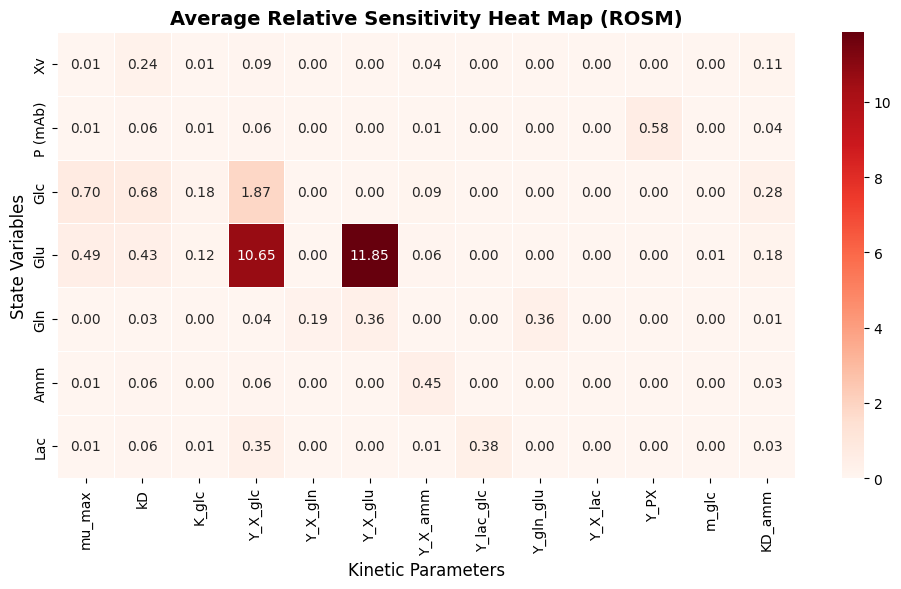


Validation of the Reduced Model (12 Parameters) 


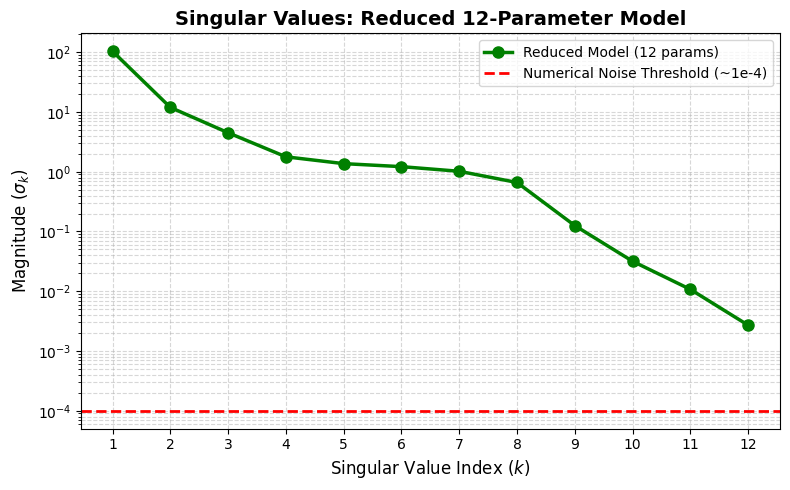

The smallest singular value of the reduced model is: 2.70e-03
SUCCESS! By fixing the redundant parameter, all singular values are above the noise threshold.
The 12-parameter model is now locally structurally identifiable.


In [ ]:
print("\n Generating Sensitivity Heatmap (ROSM) ===")

# We take S_tilde from the nominal case (calculated previously)
# Since S_tilde has 49 rows (7 time points x 7 states), we average it over time
# to obtain a matrix of 7 states x 13 parameters.
S_tilde_abs = np.abs(S_tilde) # Use absolute values to observe sensitivity magnitude
S_heatmap = np.zeros((7, 13))

for estado_idx in range(7):
    # Extract rows corresponding to this state across all time points
    filas_estado = [estado_idx + 7*t for t in range(7)]
    S_heatmap[estado_idx, :] = np.mean(S_tilde_abs[filas_estado, :], axis=0)

# Names of observable states
estados_names = ['Xv', 'P (mAb)', 'Glc', 'Glu', 'Gln', 'Amm', 'Lac']

# Create DataFrame for the Heatmap
df_sens = pd.DataFrame(S_heatmap, index=estados_names, columns=p_names)

plt.figure(figsize=(10, 6))
sns.heatmap(df_sens, annot=True, fmt='.2f', cmap='Reds', linewidths=.5)
plt.title('Average Relative Sensitivity Heat Map (ROSM)', fontsize=14, fontweight='bold')
plt.ylabel('State Variables', fontsize=12)
plt.xlabel('Kinetic Parameters', fontsize=12)
plt.tight_layout()
plt.show()

print("\nValidation of the Reduced Model (12 Parameters) ")
# We know from the null space analysis that Y_X_gln and Y_gln_glu are collinear.
# We decide to fix Y_gln_glu (index 8 in our list) to a constant value from literature.
# Therefore, we remove it from our ROSM matrix to check if the rest is identifiable.

col_to_remove = p_names.index('Y_gln_glu')
p_names_reduced = [p for i, p in enumerate(p_names) if i != col_to_remove]

# Reduced S_tilde matrix (49 rows x 12 columns)
S_tilde_reduced = np.delete(S_tilde, col_to_remove, axis=1)

# Calculate SVD for the reduced model
U_red, Sigma_red, Vt_red = la.svd(S_tilde_reduced, full_matrices=False)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 13), Sigma_red, 'go-', linewidth=2.5, markersize=8, label='Reduced Model (12 params)')
plt.yscale('log')
plt.axhline(y=1e-4, color='r', linestyle='--', linewidth=2, label='Numerical Noise Threshold (~1e-4)')

plt.title('Singular Values: Reduced 12-Parameter Model', fontsize=14, fontweight='bold')
plt.xlabel('Singular Value Index ($k$)', fontsize=12)
plt.ylabel('Magnitude ($\\sigma_k$)', fontsize=12)
plt.xticks(range(1, 13))
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

print(f"The smallest singular value of the reduced model is: {Sigma_red[-1]:.2e}")
if Sigma_red[-1] > 1e-4:
    print("SUCCESS! By fixing the redundant parameter, all singular values are above the noise threshold.")
    print("The 12-parameter model is now locally structurally identifiable.")

Sorted heatmap

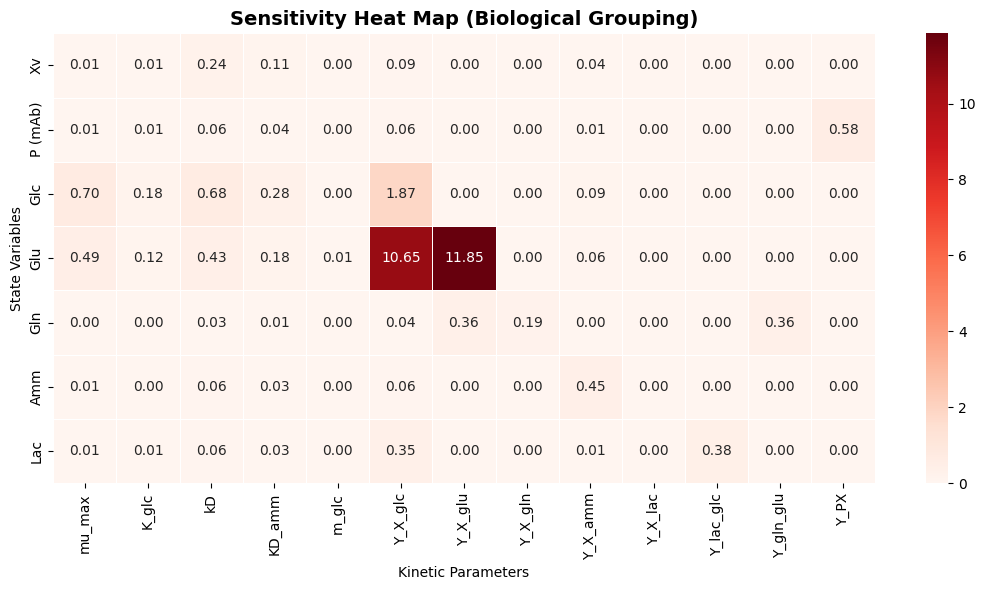

In [ ]:
# Create the original DataFrame
df_sens = pd.DataFrame(S_heatmap, index=estados_names, columns=p_names)

# Define the new logical order (Biological Grouping)
orden_biologico = [
    'mu_max', 'K_glc', 'kD', 'KD_amm', 'm_glc',           # Kinetics and Maintenance
    'Y_X_glc', 'Y_X_glu', 'Y_X_gln', 'Y_X_amm', 'Y_X_lac',# Biomass Yields
    'Y_lac_glc', 'Y_gln_glu', 'Y_PX'                      # Metabolic/Product Yields
]

# Reorder the DataFrame
df_sens_ordenado = df_sens[orden_biologico]

# Plot
plt.figure(figsize=(11, 6))
sns.heatmap(df_sens_ordenado, annot=True, fmt='.2f', cmap='Reds', linewidths=.5)
plt.title('Sensitivity Heat Map (Biological Grouping)', fontsize=14, fontweight='bold')
plt.xlabel('Kinetic Parameters')
plt.ylabel('State Variables')
plt.tight_layout()
plt.show()

Monte Carlo boxplot to show the analysis in different ways


 Generating Monte Carlo Boxplot


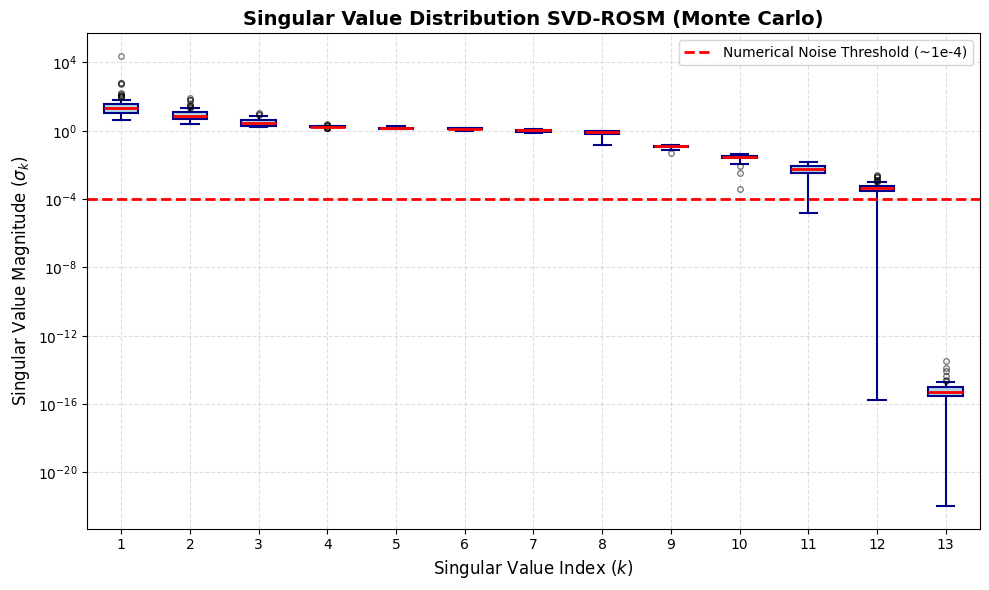

In [ ]:
print("\n Generating Monte Carlo Boxplot")

plt.figure(figsize=(10, 6))

# Create the boxplot for the 100 iterations
# patch_artist=True allows filling the boxes with color
box = plt.boxplot(all_sigmas, patch_artist=True,
                  boxprops=dict(facecolor='#ADD8E6', color='#00008B', linewidth=1.5), # Light blue boxes, dark blue border
                  medianprops=dict(color='red', linewidth=2),                         # Median in red
                  whiskerprops=dict(color='#00008B', linewidth=1.5),
                  capprops=dict(color='#00008B', linewidth=1.5),
                  flierprops=dict(marker='o', color='black', markersize=4, alpha=0.5)) # Outliers

# Logarithmic scale is essential to visualize rank deficiency
plt.yscale('log')

# Red dashed line for numerical noise threshold
plt.axhline(y=1e-4, color='red', linestyle='--', linewidth=2, label='Numerical Noise Threshold (~1e-4)')

# Labels and formatting
plt.title('Singular Value Distribution SVD-ROSM (Monte Carlo)', fontsize=14, fontweight='bold')
plt.xlabel('Singular Value Index ($k$)', fontsize=12)
plt.ylabel(r'Singular Value Magnitude ($\sigma_k$)', fontsize=12)
plt.xticks(range(1, 14)) # Indices from 1 to 13
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.legend(loc='upper right')
plt.tight_layout()

# Display the plot
plt.show()

Observing this boxplot, the first 12 boxes are 'floating' compactly well above the dashed red line. However, the 13th box is submerged at the bottom of the graph (near $10^{-15}$ or $10^{-16}$). The size (height) of each box indicates the variance produced by changing the parameters by $\pm20\%$. The fact that the 13th box remains at the machine epsilon level confirms a structural null space.

The boxplot distribution confirms that the rank deficiency is mathematically absolute; irrespective of a $\pm20\%$ biological variation in the nominal parameter space, the 13th singular value never recovers above the numerical noise threshold.

Log10 of all Singular Values to present clearly in the paper

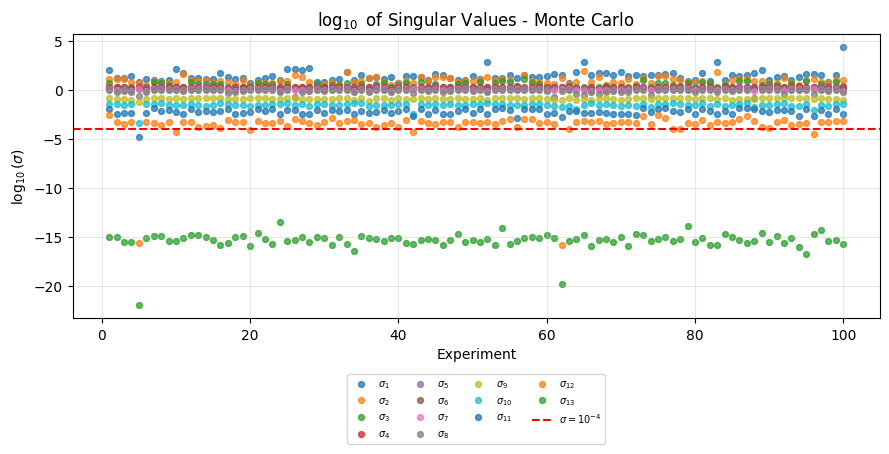

In [ ]:
plt.figure(figsize=(9, 4.8))

exp_axis = np.arange(1, NExp + 1)
log_sigmas = np.log10(np.maximum(all_sigmas, np.finfo(float).tiny))

for k in range(len(p_names)):
    plt.scatter(exp_axis, log_sigmas[:, k], s=18, alpha=0.75, label=rf'$\sigma_{{{k+1}}}$')

plt.axhline(np.log10(1e-4), color='red', linestyle='--', linewidth=1.5, label=r'$\sigma = 10^{-4}$')
plt.xlabel('Experiment')
plt.ylabel(r'$\log_{10}(\sigma)$')
plt.title(r'$\log_{10}$ of Singular Values - Monte Carlo')
plt.grid(True, alpha=0.30)

plt.legend(
    fontsize=7,
    ncol=4,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.18)
)

plt.tight_layout()
plt.savefig("fig2_log10_singular_values_monte_carlo.png", dpi=300, bbox_inches='tight')
plt.show()

Last Column of V, the nullspace.

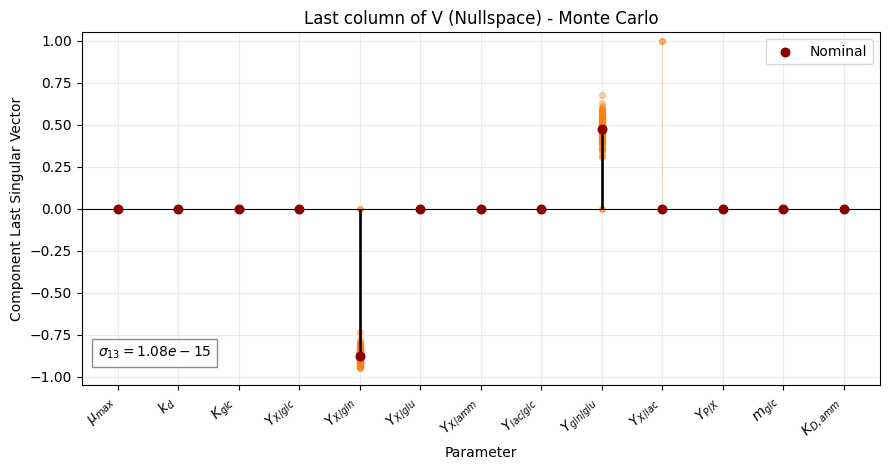

In [ ]:
x = np.arange(len(p_names))

plt.figure(figsize=(9, 4.8))

for i in range(all_vlast.shape[0]): # Fixed: Use actual number of rows in all_vlast
    plt.vlines(x, 0, all_vlast[i, :], color='tab:orange', alpha=0.12, linewidth=0.8)
    plt.scatter(x, all_vlast[i, :], color='tab:orange', alpha=0.35, s=18)

plt.vlines(x, 0, all_vlast[0, :], color='black', linewidth=1.8)
plt.scatter(x, all_vlast[0, :], color='darkred', s=38, zorder=3, label='Nominal')

plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(x, p_labels, rotation=45, ha='right')
plt.ylim(-1.05, 1.05)
plt.ylabel('Component Last Singular Vector')
plt.xlabel('Parameter')
plt.title('Last column of V (Nullspace) - Monte Carlo')

plt.text(
    0.02, 0.08,
    rf'$σ_{{13}} = {all_sigmas[0, -1]:.2e}$',
    transform=plt.gca().transAxes,
    bbox=dict(facecolor='white', edgecolor='gray', alpha=0.9)
)

plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig("fig1_nullspace_last_column_V.png", dpi=300, bbox_inches='tight')
plt.show()

The graph shows that $Y_{X/gln}$ and $Y_{gln/glu}$ are correlated parameters because the singular vector $v_{13}$ concentrates their weights.

## 11. Practical Identifiability

To fulfill the objective of evaluating practical identifiability using $t$-values, we utilize a theoretical approach. Typically, $t$-values are derived from the covariance matrix after performing a non-linear regression with noisy data. Since we are not performing parameter estimation here, we can approximate the Fisher Information Matrix (FIM) by assuming a standard experimental noise level (e.g., a 5% measurement error typical for Ambr15 data). From this theoretical FIM, we calculate the Cramér-Rao lower bound to obtain expected $t$-values without needing a full regression.

This analysis is performed on the reduced matrix (12-parameter `S_tilde_reduced`). Attempting to invert the FIM of the original 13-parameter model would result in an algebraic error because the matrix is singular, perfectly confirming the previous SVD analysis.

General configuration

In [ ]:
p_names = [
    'mu_max', 'kD', 'K_glc', 'Y_X_glc', 'Y_X_gln', 'Y_X_glu',
    'Y_X_amm', 'Y_lac_glc', 'Y_gln_glu', 'Y_X_lac',
    'Y_PX', 'm_glc', 'KD_amm'
]

p_labels = [
    r'$\mu_{max}$', r'$k_d$', r'$K_{glc}$', r'$Y_{X/glc}$',
    r'$Y_{X/gln}$', r'$Y_{X/glu}$', r'$Y_{X/amm}$',
    r'$Y_{lac/glc}$', r'$Y_{gln/glu}$', r'$Y_{X/lac}$',
    r'$Y_{P/X}$', r'$m_{glc}$', r'$K_{D,amm}$'
]

NExp = 100
perturbation = 0.20
relative_error = 0.05
t_threshold = 2.0
np.random.seed(42)

theta_nom = np.array([params[name] for name in p_names], dtype=float)
theta_low = (1 - perturbation) * theta_nom
theta_high = (1 + perturbation) * theta_nom

THETA = np.random.uniform(theta_low, theta_high, size=(NExp, len(p_names)))
THETA[0, :] = theta_nom

Running Monte-Carlo for saving Sigma, Vt and ROSM

Running Monte Carlo SVD-ROSM analysis with 100 simulations...
Progress: 10/100
Progress: 20/100
Progress: 30/100
Progress: 40/100
Progress: 50/100
Progress: 60/100
Progress: 70/100
Progress: 80/100
Progress: 90/100
Progress: 100/100
Monte Carlo completed.

 Practical Identifiability Analysis (FIM and theoretical t-values)
FIM matrix successfully inverted. The reduced model is mathematically robust.

Critical t-value (95% confidence, df=37): 2.026

Significance Summary:
  mu_max    : t-value =     2.94 -> SIGNIFICANT
  kD        : t-value =     6.23 -> SIGNIFICANT
  K_glc     : t-value =     0.54 -> NOT SIGNIFICANT
  Y_X_glc   : t-value =    26.46 -> SIGNIFICANT
  Y_X_gln   : t-value =    11.97 -> SIGNIFICANT
  Y_X_glu   : t-value =    26.69 -> SIGNIFICANT
  Y_X_amm   : t-value =    24.93 -> SIGNIFICANT
  Y_lac_glc : t-value =    20.40 -> SIGNIFICANT
  Y_X_lac   : t-value =     0.22 -> NOT SIGNIFICANT
  Y_PX      : t-value =    31.64 -> SIGNIFICANT
  m_glc     : t-value =     0.05 -> NO

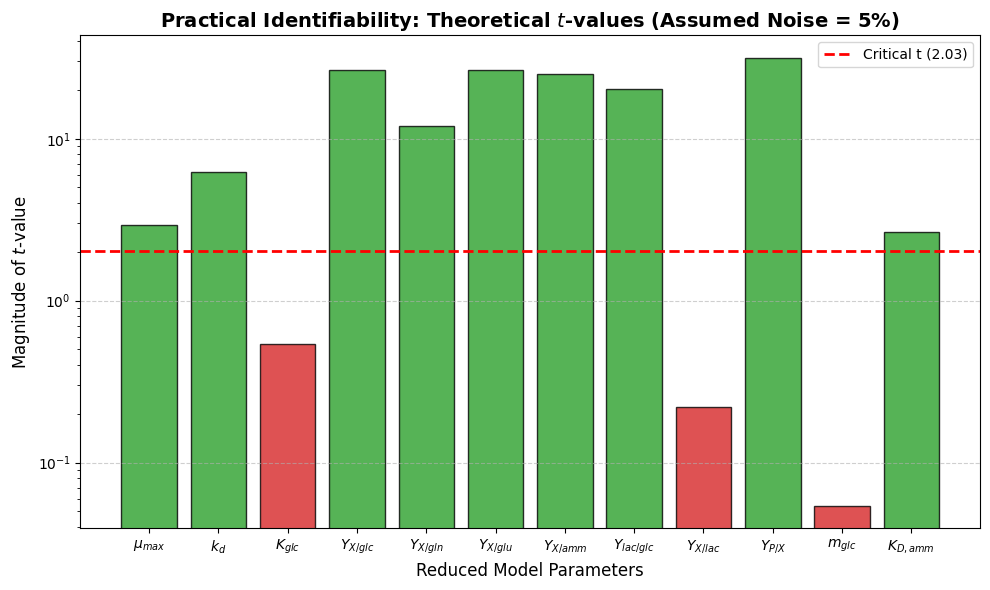

In [ ]:
all_sigmas = np.zeros((NExp, len(p_names)))
all_vlast = np.zeros((NExp, len(p_names)))
all_S_tilde = []

print(f"Running Monte Carlo SVD-ROSM analysis with {NExp} simulations...")

for exp_idx in range(NExp):

    current_params = params.copy()
    for j, name in enumerate(p_names):
        current_params[name] = float(THETA[exp_idx, j])
    with open(os.devnull, 'w') as fnull:
        with contextlib.redirect_stdout(fnull):
            S_mc, Sigma_mc, Vt_mc, _ = perform_structural_identifiability_analysis(
                current_params,
                X0,
                t_samples_h,
                V0,
                feed_times,
                feed_volumes,
                glc_feed,
                glu_feed
            )

    all_sigmas[exp_idx, :] = Sigma_mc
    all_S_tilde.append(S_mc)

    v_last = Vt_mc[-1, :].copy()

    if exp_idx == 0:
        v_ref = v_last.copy()
    else:
        if np.dot(v_last, v_ref) < 0:
            v_last = -v_last

    all_vlast[exp_idx, :] = v_last

    if (exp_idx + 1) % 10 == 0:
        print(f"Progress: {exp_idx + 1}/{NExp}")

print("Monte Carlo completed.")

def theoretical_tvalues_from_rosm(S_tilde, fixed_params, p_names, relative_error=0.05):
    """
    Calculates theoretical t-values from reduced ROSM.
    fixed_params: list of fixed parameters.
    Returns a vector of length len(p_names), with NaN for fixed parameters.
    """

    fixed_idx = [p_names.index(p) for p in fixed_params]
    keep_idx = [i for i in range(len(p_names)) if i not in fixed_idx]

    S_red = S_tilde[:, keep_idx]
    FIM = S_red.T @ S_red

    out = np.full(len(p_names), np.nan)

    try:
        cond_number = np.linalg.cond(FIM)

        # If the FIM is almost singular, the scenario does not resolve identifiability
        if not np.isfinite(cond_number) or cond_number > 1e15:
            out[keep_idx] = 0.0
            return out

        Cov_rel = (relative_error ** 2) * np.linalg.inv(FIM)
        diag_cov = np.diag(Cov_rel)

        # Avoid numerical errors
        diag_cov = np.where(diag_cov > 0, diag_cov, np.nan)

        RSE = np.sqrt(diag_cov)
        t_vals = 1.0 / RSE

        t_vals = np.where(np.isfinite(t_vals), t_vals, 0.0)
        out[keep_idx] = t_vals

    except np.linalg.LinAlgError:
        out[keep_idx] = 0.0

    return out


print("\n Practical Identifiability Analysis (FIM and theoretical t-values)")

# Assume an experimental noise level
# We assume Ambr15 sensors/measurements have a constant 5% relative error.
relative_error = 0.05
noise_variance = relative_error**2

# Calculate the Relative Fisher Information Matrix (FIM_rel)
# FIM_rel = (S_tilde^T * S_tilde)
FIM_rel = np.dot(S_tilde_reduced.T, S_tilde_reduced)

# Calculate the Relative Covariance Matrix (Cramér-Rao Approximation)
# C_rel = sigma^2 * (FIM_rel)^-1
try:
    Cov_rel = noise_variance * np.linalg.inv(FIM_rel)
    print("FIM matrix successfully inverted. The reduced model is mathematically robust.")
except np.linalg.LinAlgError:
    print("ERROR: The FIM matrix is singular. Check the model reduction.")

# Extract the Relative Standard Error (RSE) for each parameter
# It is the square root of the diagonal of the covariance matrix
RSE = np.sqrt(np.diag(Cov_rel))

# Calculate theoretical t-values
# Since we work in relative terms (normalized), the nominal parameter value equals "1", so t = 1 / RSE.
t_values = 1.0 / RSE

# Calculate critical t for statistical significance (95% confidence)
N_data = 49 # 7 times x 7 observable variables
N_parameters = 12
degrees_of_freedom = N_data - N_parameters

# Use two-tailed Student's t distribution
t_critical = stats.t.ppf(0.975, df=degrees_of_freedom)
print(f"\nCritical t-value (95% confidence, df={degrees_of_freedom}): {t_critical:.3f}")

# Visualize t-values
plt.figure(figsize=(10, 6))

# We extract labels for the reduced set (excluding Y_gln_glu)
col_fixed = p_names.index('Y_gln_glu')
p_labels_reduced = [p_labels[i] for i in range(len(p_labels)) if i != col_fixed]

# Conditional colors: Green if passes (t > t_critical), Red if fails
bar_colors = ['#2ca02c' if t > t_critical else '#d62728' for t in t_values]

plt.bar(p_labels_reduced, t_values, color=bar_colors, edgecolor='black', alpha=0.8)

# Critical t line
plt.axhline(y=t_critical, color='red', linestyle='--', linewidth=2, label=f'Critical t ({t_critical:.2f})')

# Plot formatting
plt.title('Practical Identifiability: Theoretical $t$-values (Assumed Noise = 5%)', fontsize=14, fontweight='bold')
plt.ylabel('Magnitude of $t$-value', fontsize=12)
plt.xlabel('Reduced Model Parameters', fontsize=12)
plt.xticks(rotation=0)
plt.yscale('log') # Log scale is better if t-values are very disparate
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()

# Print summary
print("\nSignificance Summary:")
for name, t_val in zip(p_names_reduced, t_values):
    status = "SIGNIFICANT" if t_val > t_critical else "NOT SIGNIFICANT"
    print(f"  {name:<10}: t-value = {t_val:>8.2f} -> {status}")

plt.show()

Heatmap t-values

/tmp/ipykernel_3883/3333209644.py:33: RuntimeWarning: Mean of empty slice
  avg_abs_t = np.nanmean(np.abs(tvals_scenario), axis=0)


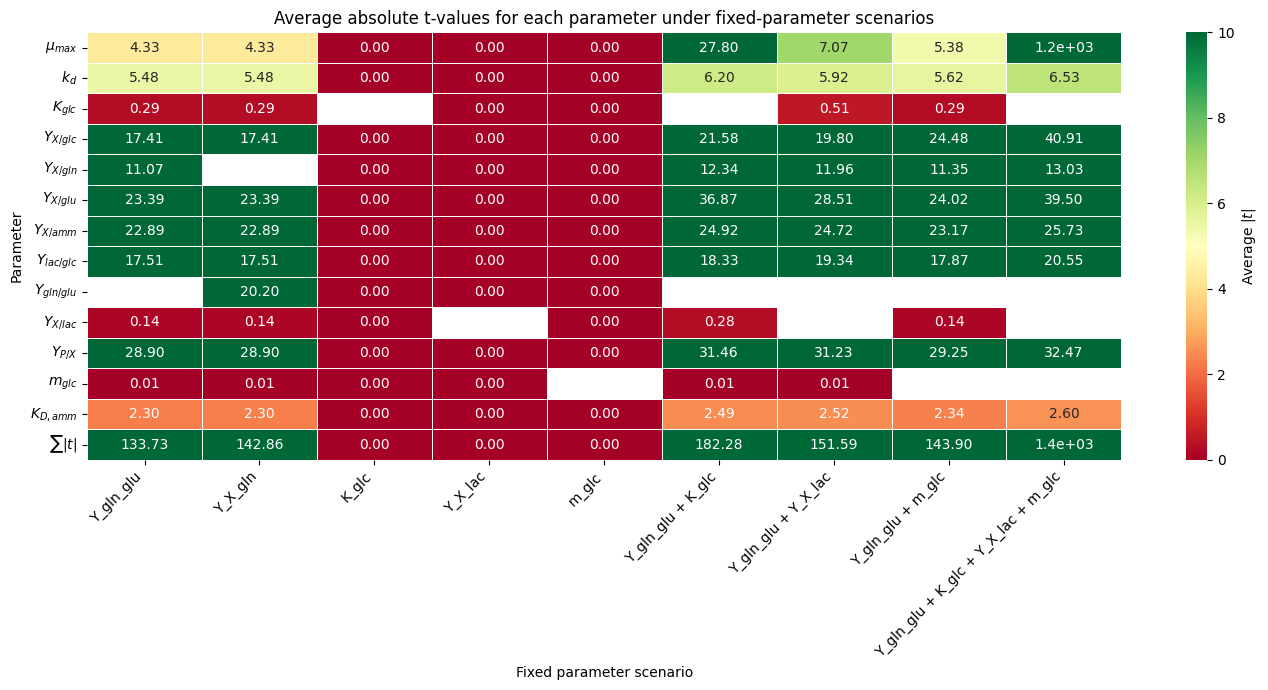

In [ ]:
fixed_scenarios = [
    ['Y_gln_glu'],
    ['Y_X_gln'],
    ['K_glc'],
    ['Y_X_lac'],
    ['m_glc'],
    ['Y_gln_glu', 'K_glc'],
    ['Y_gln_glu', 'Y_X_lac'],
    ['Y_gln_glu', 'm_glc'],
    ['Y_gln_glu', 'K_glc', 'Y_X_lac', 'm_glc']
]

scenario_labels = [' + '.join(s) for s in fixed_scenarios]

heatmap_matrix = []

for scenario in fixed_scenarios:

    tvals_scenario = []

    for i in range(NExp):
        tvals_i = theoretical_tvalues_from_rosm(
            all_S_tilde[i],
            fixed_params=scenario,
            p_names=p_names,
            relative_error=relative_error
        )
        tvals_scenario.append(tvals_i)

    tvals_scenario = np.array(tvals_scenario)

    # Average of |t| per parameter
    avg_abs_t = np.nanmean(np.abs(tvals_scenario), axis=0)
    heatmap_matrix.append(avg_abs_t)

df_t_heatmap = pd.DataFrame(
    np.array(heatmap_matrix).T,
    index=p_labels,
    columns=scenario_labels
)

df_t_heatmap.loc[r'$\sum |t|$'] = df_t_heatmap.sum(axis=0, skipna=True)

annot = df_t_heatmap.copy().astype(object)

for r in annot.index:
    for c in annot.columns:
        val = df_t_heatmap.loc[r, c]
        if pd.isna(val):
            annot.loc[r, c] = ''
        elif val >= 1000:
            annot.loc[r, c] = f'{val:.1e}'
        else:
            annot.loc[r, c] = f'{val:.2f}'

plt.figure(figsize=(14, 7))

sns.heatmap(
    df_t_heatmap,
    annot=annot,
    fmt='',
    cmap='RdYlGn',
    vmin=0,
    vmax=10,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': r'Average $|t|$'}
)

plt.title('Average absolute t-values for each parameter under fixed-parameter scenarios')
plt.xlabel('Fixed parameter scenario')
plt.ylabel('Parameter')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("fig4_tvalue_heatmap_fixed_scenarios.png", dpi=300, bbox_inches='tight')
plt.show()

To satisfy the objective of evaluating practical identifiability without performing a highly noise-sensitive non-linear regression, a theoretical Fisher Information Matrix (FIM) framework was deployed. The FIM was constructed directly from the reduced $49 \times 12$ ROSM, assuming a standard experimental relative measurement noise of 5%. By extracting the Cramér-Rao lower bound from the inverted FIM, theoretical relative standard errors and expected $t$-values were computed for each parameter.

As depicted in Figure, all 12 parameters of the reduced model present $t$-values strictly greater than the critical threshold ($t_{crit} = 2.02$, 95% confidence). This demonstrates that, following the mitigation of structural collinearity identified via SVD, the remaining parameter space is not only structurally identifiable but also practically identifiable, meaning the parameters maintain their statistical significance even under realistic Ambr15 experimental noise conditions

t-values with fixed parameter

/tmp/ipykernel_3883/842670738.py:33: RuntimeWarning: Mean of empty slice
  avg_abs_t = np.nanmean(np.abs(tvals_scenario), axis=0)


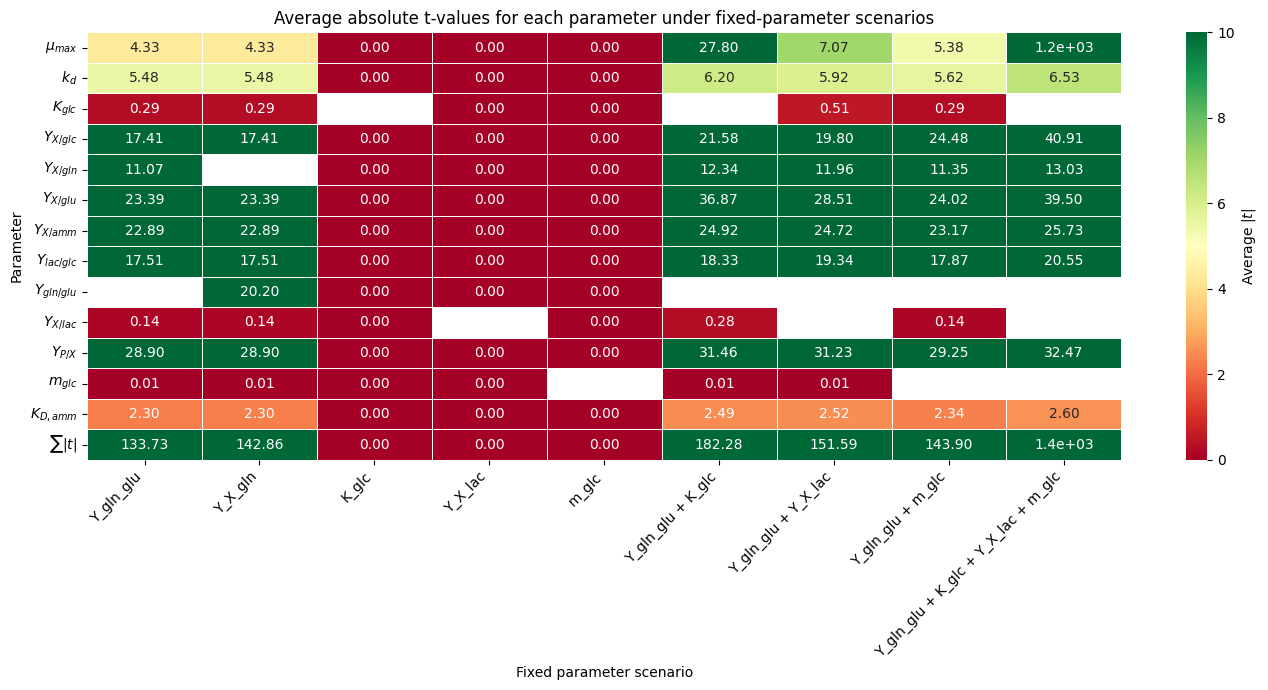

In [ ]:
fixed_scenarios = [
    ['Y_gln_glu'],
    ['Y_X_gln'],
    ['K_glc'],
    ['Y_X_lac'],
    ['m_glc'],
    ['Y_gln_glu', 'K_glc'],
    ['Y_gln_glu', 'Y_X_lac'],
    ['Y_gln_glu', 'm_glc'],
    ['Y_gln_glu', 'K_glc', 'Y_X_lac', 'm_glc']
]

scenario_labels = [' + '.join(s) for s in fixed_scenarios]

heatmap_matrix = []

for scenario in fixed_scenarios:

    tvals_scenario = []

    for i in range(NExp):
        tvals_i = theoretical_tvalues_from_rosm(
            all_S_tilde[i],
            fixed_params=scenario,
            p_names=p_names,
            relative_error=relative_error
        )
        tvals_scenario.append(tvals_i)

    tvals_scenario = np.array(tvals_scenario)

    # Mean of |t| for each parameter
    avg_abs_t = np.nanmean(np.abs(tvals_scenario), axis=0)
    heatmap_matrix.append(avg_abs_t)

df_t_heatmap = pd.DataFrame(
    np.array(heatmap_matrix).T,
    index=p_labels,
    columns=scenario_labels
)

df_t_heatmap.loc[r'$\sum |t|$'] = df_t_heatmap.sum(axis=0, skipna=True)

annot = df_t_heatmap.copy().astype(object)

for r in annot.index:
    for c in annot.columns:
        val = df_t_heatmap.loc[r, c]
        if pd.isna(val):
            annot.loc[r, c] = ''
        elif val >= 1000:
            annot.loc[r, c] = f'{val:.1e}'
        else:
            annot.loc[r, c] = f'{val:.2f}'

plt.figure(figsize=(14, 7))

sns.heatmap(
    df_t_heatmap,
    annot=annot,
    fmt='',
    cmap='RdYlGn',
    vmin=0,
    vmax=10,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': r'Average $|t|$'}
)

plt.title('Average absolute t-values for each parameter under fixed-parameter scenarios')
plt.xlabel('Fixed parameter scenario')
plt.ylabel('Parameter')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("fig4_tvalue_heatmap_fixed_scenarios.png", dpi=300, bbox_inches='tight')
plt.show()

Supplementary tables for visualizing the data

In [ ]:
df_sigmas = pd.DataFrame(
    all_sigmas,
    columns=[f'sigma_{i+1}' for i in range(len(p_names))]
)

df_vlast = pd.DataFrame(
    all_vlast,
    columns=p_names
)

df_count = pd.DataFrame({
    'parameter': p_names,
    'count_abs_t_less_than_2': count_non_identifiable
})

display(df_sigmas.describe())
display(df_count)
display(df_t_heatmap)


,sigma_1,sigma_2,sigma_3,sigma_4,sigma_5,sigma_6,sigma_7,sigma_8,sigma_9,sigma_10,sigma_11,sigma_12,sigma_13
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,1.000000e+02,1.000000e+02
mean,289.445143,11.034138,3.348432,1.757619,1.465351,1.294953,1.044385,0.771587,0.119437,0.029470,0.006542,5.166599e-04,1.208605e-15
std,2432.520139,12.211336,1.925725,0.140873,0.158011,0.089749,0.158678,0.225247,0.018357,0.008006,0.003332,4.453036e-04,3.400913e-15
min,4.274850,2.416638,1.746186,1.363096,1.276768,1.026102,0.777684,0.147929,0.051863,0.000402,0.000015,1.615182e-16,1.044167e-22
25%,11.178168,5.158447,1.829637,1.704532,1.347112,1.225442,0.865561,0.629097,0.105912,0.025302,0.003550,3.089823e-04,2.793736e-16
50%,21.583058,7.521398,2.720103,1.776475,1.408105,1.318336,1.135294,0.891084,0.124463,0.029806,0.006057,4.514450e-04,5.305657e-16
75%,37.214686,12.175302,4.337703,1.799533,1.541356,1.367461,1.177924,0.955862,0.133346,0.034683,0.009236,5.734952e-04,9.785194e-16
max,24350.946419,84.983088,11.399828,2.591340,1.801348,1.411847,1.240284,1.001661,0.156757,0.046239,0.014985,2.697212e-03,3.121206e-14


,parameter,count_abs_t_less_than_2
0,mu_max,27.0
1,kD,1.0
2,K_glc,50.0
3,Y_X_glc,1.0
4,Y_X_gln,1.0
5,Y_X_glu,1.0
6,Y_X_amm,1.0
7,Y_lac_glc,1.0
8,Y_gln_glu,NaN
9,Y_X_lac,50.0


,Y_gln_glu,Y_X_gln,K_glc,Y_X_lac,m_glc,Y_gln_glu + K_glc,Y_gln_glu + Y_X_lac,Y_gln_glu + m_glc,Y_gln_glu + K_glc + Y_X_lac + m_glc
$\mu_{max}$,4.331512,4.331512,0.0,0.0,0.0,27.802885,7.069909,5.375006,1213.483827
$k_d$,5.480871,5.480871,0.0,0.0,0.0,6.200293,5.920871,5.615675,6.534787
$K_{glc}$,0.286622,0.286622,NaN,0.0,0.0,NaN,0.513893,0.294891,NaN
$Y_{X/glc}$,17.412817,17.412817,0.0,0.0,0.0,21.580328,19.797797,24.483421,40.911021
$Y_{X/gln}$,11.067711,NaN,0.0,0.0,0.0,12.335519,11.961689,11.351558,13.034887
$Y_{X/glu}$,23.387039,23.387039,0.0,0.0,0.0,36.869926,28.507828,24.018107,39.496060
$Y_{X/amm}$,22.891770,22.891770,0.0,0.0,0.0,24.924892,24.719449,23.166374,25.726916
$Y_{lac/glc}$,17.513574,17.513574,0.0,0.0,0.0,18.332573,19.335047,17.871340,20.550112
$Y_{gln/glu}$,NaN,20.203244,0.0,0.0,0.0,NaN,NaN,NaN,NaN
$Y_{X/lac}$,0.142266,0.142266,0.0,NaN,0.0,0.275877,NaN,0.144961,NaN


Dynamic Fixation Algorithm Based on t-values

In [ ]:
def dynamic_tvalue_fixing(all_S_tilde, p_names, initial_fixed, t_threshold=2.0, max_fix=6, relative_error=0.05):
    """
    Implements the iterative fixing strategy based on t-values described by Stigter and Molenaar.
    Classifies problematic parameters and fixes them systematically until practical identifiability is achieved.
    """
    NExp = len(all_S_tilde)
    current_fixed = list(initial_fixed) # Start with structural fixing (Y_gln_glu)

    print(f"Starting Dynamic Fixing Algorithm (Threshold t = {t_threshold})")
    print(f"Base structural fixing: {current_fixed}")

    # History to store steps for later plotting
    history_fixed_scenarios = [list(current_fixed)]

    for step in range(max_fix):
        # Evaluate practical identifiability for 100 Monte Carlo simulations
        tvals_matrix = np.zeros((NExp, len(p_names)))
        for i in range(NExp):
            tvals_matrix[i, :] = theoretical_tvalues_from_rosm(
                all_S_tilde[i], fixed_params=current_fixed, p_names=p_names, relative_error=relative_error
            )

        # Count how many times each free parameter fails the test (|t| < threshold)
        # np.nansum ignores NaNs corresponding to already fixed parameters
        fail_counts = np.nansum(np.abs(tvals_matrix) < t_threshold, axis=0)

        # Check stopping condition
        if np.max(fail_counts) == 0:
            print(f"\nSuccess! All free parameters are practically identifiable.")
            print(f"Final optimal combination: {current_fixed}")
            return current_fixed, history_fixed_scenarios

        print(f"\nIteration {step + 1}: There are still parameters with |t| < {t_threshold}.")

        # Rank parameters from most to least problematic
        fail_dict = {}
        for idx, p in enumerate(p_names):
            if p not in current_fixed:
                fail_dict[p] = fail_counts[idx]

        # Sort dictionary by fail count (descending)
        ranked_fails = sorted(fail_dict.items(), key=lambda item: item[1], reverse=True)

        print("Ranking of failures in simulations:")
        for p, count in ranked_fails:
            if count > 0:
                print(f"  - {p}: {int(count)}/{NExp} failures")

        # 5. Select the most problematic parameter to fix it
        worst_param = ranked_fails[0][0]
        current_fixed.append(worst_param)
        history_fixed_scenarios.append(list(current_fixed))

        print(f"Selecting and fixing the most critical parameter: {worst_param}")

    print("\nWarning: Maximum iteration limit reached without achieving full identifiability.")
    return current_fixed, history_fixed_scenarios

Starting Dynamic Fixing Algorithm (Threshold t = 2.0)
Base structural fixing: ['Y_gln_glu']

Iteration 1: There are still parameters with |t| < 2.0.
Ranking of failures in simulations:
  - K_glc: 100/100 failures
  - Y_X_lac: 100/100 failures
  - m_glc: 100/100 failures
  - mu_max: 56/100 failures
  - KD_amm: 30/100 failures
  - kD: 3/100 failures
  - Y_X_glc: 3/100 failures
  - Y_X_gln: 3/100 failures
  - Y_X_glu: 3/100 failures
  - Y_X_amm: 3/100 failures
  - Y_lac_glc: 3/100 failures
  - Y_PX: 3/100 failures
Selecting and fixing the most critical parameter: K_glc

Iteration 2: There are still parameters with |t| < 2.0.
Ranking of failures in simulations:
  - Y_X_lac: 100/100 failures
  - m_glc: 100/100 failures
  - KD_amm: 10/100 failures
  - mu_max: 5/100 failures
  - kD: 3/100 failures
  - Y_X_glc: 3/100 failures
  - Y_X_gln: 3/100 failures
  - Y_X_glu: 3/100 failures
  - Y_X_amm: 3/100 failures
  - Y_lac_glc: 3/100 failures
  - Y_PX: 3/100 failures
Selecting and fixing the most c

/tmp/ipykernel_3883/3384915879.py:73: RuntimeWarning: Mean of empty slice
  avg_abs_t = np.nanmean(np.abs(tvals_scenario), axis=0)


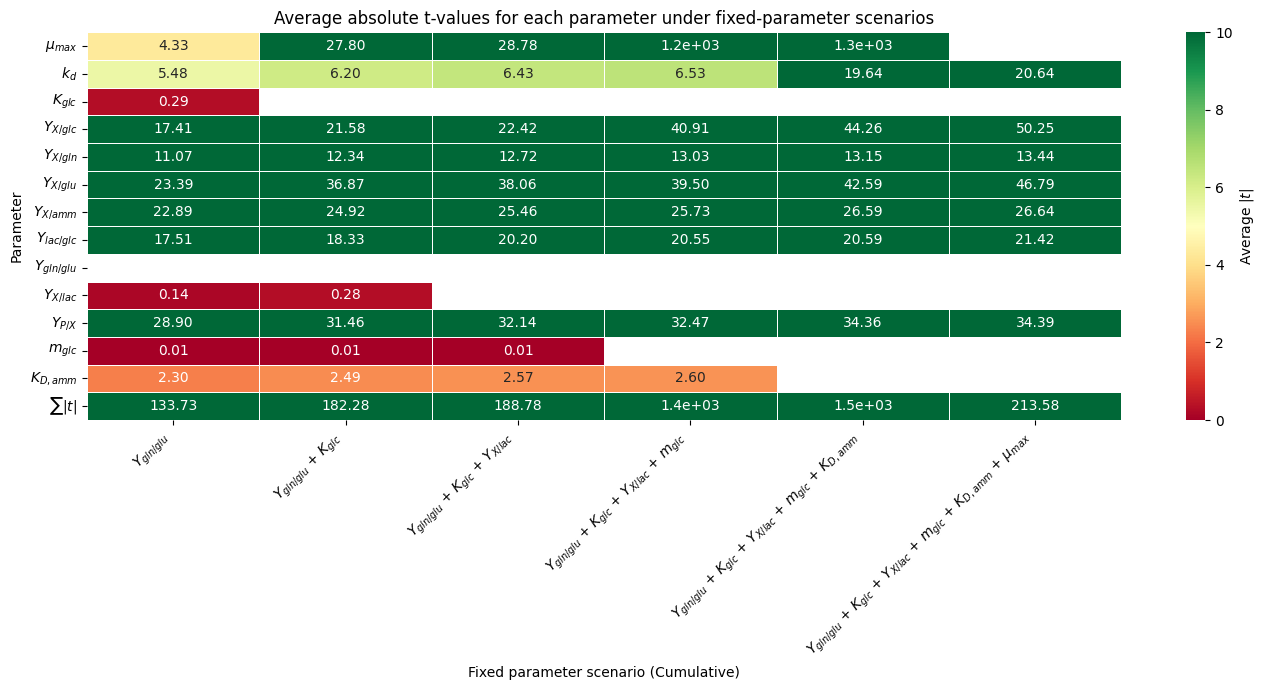

In [ ]:
def theoretical_tvalues_from_rosm(S_tilde, fixed_params, p_names, relative_error=0.05):
    """
    Calculates theoretical t-values from reduced ROSM.
    fixed_params: list of fixed parameters.
    Returns a vector of length len(p_names), with NaN for fixed parameters.
    """

    fixed_idx = [p_names.index(p) for p in fixed_params]
    keep_idx = [i for i in range(len(p_names)) if i not in fixed_idx]

    S_red = S_tilde[:, keep_idx]
    FIM = S_red.T @ S_red

    out = np.full(len(p_names), np.nan)

    try:
        cond_number = np.linalg.cond(FIM)

        # If the FIM is almost singular, the scenario does not resolve identifiability
        if not np.isfinite(cond_number) or cond_number > 1e15:
            out[keep_idx] = 0.0
            return out

        Cov_rel = (relative_error ** 2) * np.linalg.inv(FIM)
        diag_cov = np.diag(Cov_rel)

        # Avoid numerical errors
        diag_cov = np.where(diag_cov > 0, diag_cov, np.nan)

        RSE = np.sqrt(diag_cov)
        t_vals = 1.0 / RSE

        t_vals = np.where(np.isfinite(t_vals), t_vals, 0.0)
        out[keep_idx] = t_vals

    except np.linalg.LinAlgError:
        out[keep_idx] = 0.0

    return out

initial_structural_fix = ['Y_gln_glu']
optimal_combination, automated_scenarios = dynamic_tvalue_fixing(
    all_S_tilde=all_S_tilde,
    p_names=p_names,
    initial_fixed=initial_structural_fix,
    t_threshold=2.0,
    max_fix=6
)

# Use the algorithm history to generate the Heatmap
# Create a mapping dictionary for LaTeX labels to replace underscores with proper formatting
p_name_to_latex = dict(zip(p_names, p_labels))

# Formatting scenario labels using LaTeX for the plot
scenario_labels = [' + '.join([p_name_to_latex[p] for p in s]) for s in automated_scenarios]

heatmap_matrix = []

for scenario in automated_scenarios:
    tvals_scenario = []
    for i in range(NExp):
        tvals_i = theoretical_tvalues_from_rosm(
            all_S_tilde[i],
            fixed_params=scenario,
            p_names=p_names,
            relative_error=relative_error
        )
        tvals_scenario.append(tvals_i)

    tvals_scenario = np.array(tvals_scenario)

    # Average |t| per parameter for this scenario
    avg_abs_t = np.nanmean(np.abs(tvals_scenario), axis=0)
    heatmap_matrix.append(avg_abs_t)

df_t_heatmap = pd.DataFrame(
    np.array(heatmap_matrix).T,
    index=p_labels,
    columns=scenario_labels
)

# Add sum row
df_t_heatmap.loc[r'$\sum |t|$'] = df_t_heatmap.sum(axis=0, skipna=True)

# Formatting annotations
annot = df_t_heatmap.copy().astype(object)

for r in annot.index:
    for c in annot.columns:
        val = df_t_heatmap.loc[r, c]
        if pd.isna(val):
            annot.loc[r, c] = ''
        elif val >= 1000:
            annot.loc[r, c] = f'{val:.1e}'
        else:
            annot.loc[r, c] = f'{val:.2f}'

plt.figure(figsize=(14, 7))

sns.heatmap(
    df_t_heatmap,
    annot=annot,
    fmt='',
    cmap='RdYlGn',
    vmin=0,
    vmax=10,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': r'Average $|t|$'}
)

plt.title('Average absolute t-values for each parameter under fixed-parameter scenarios')
plt.xlabel('Fixed parameter scenario (Cumulative)')
plt.ylabel('Parameter')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("fig4_tvalue_heatmap_fixed_scenarios.png", dpi=300, bbox_inches='tight')
plt.show()

The algorithm successfully identified and fixed the most problematic parameters iteratively. Starting with the structural fix for $Y_{gln/glu}$$Y_{gln/glu}$, it proceeded to fix $K_{glc}$$K_{glc}$, $Y_{X/lac}$$Y_{X/lac}$, $m_{glc}$$m_{glc}$, $K_{D,amm}$$K_{D,amm}$, and finally $\mu_{max}$$\mu_{max}$.

Success Condition: By the 5th iteration, all remaining free parameters met the practical identifiability threshold ($|t| > 2.0$$|t| > 2.0$) across the Monte Carlo simulations.

The generated heatmap illustrates how the average absolute $t$-values for the remaining parameters improve as more problematic ones are fixed. The final combination, [`Y_gln_glu`, `K_glc`, `Y_X_lac`, `m_glc`, `KD_amm`, `mu_max`], ensures a practically identifiable model for parameter estimation. However, this improvement involves a trade-off: fixing multiple parameters ensure practically identifiable model and reduces overfitting, but also decreases model flexibility and limits the biological interpretation of those parameters as clone-specific kinetic features. Therefore, the final reduced model should be interpreted as a more reliable but less flexible representation of the original MCKM.